# 🌾 Crop Yield Prediction
### End-to-End Machine Learning Pipeline

**Goal:** Predict crop yield (kg/ha) across Indian crops from 1961–2024 using climate, soil, and agricultural features.

| | |
|---|---|
| **Dataset** | India crop yield 1961–2024 |
| **Target** | `yield_kg_ha` |
| **Best Model** | XGBoost (R² = 0.9032) |
| **Split** | Time-based — Train: 1961–2015 / Test: 2016–2024 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [10]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
    'legend.fontsize' : 9,
})

In [2]:
df = pd.read_csv('india_yield_final_dataset.csv')


## 2. Exploratory Data Analysis

We explore the dataset to understand distributions, trends, and correlations before modelling.

- How is yield distributed across crops and categories?
- How has yield changed over time?
- How do rainfall, temperature, and fertilizer relate to yield?

In [3]:
print("\n── First 5 rows ──")
print(df.head())

print("\n── Last 5 rows ──")
print(df.tail())

print("\n── Data Types ──")
print(df.dtypes)

print("\n── Dataset Info ──")
df.info()


── First 5 rows ──
                crop crop_category  year  area_harvested_ha  \
0  Almonds, in shell      Tree Nut  2011            23000.0   
1  Almonds, in shell      Tree Nut  2012            22000.0   
2  Almonds, in shell      Tree Nut  2013            21000.0   
3  Almonds, in shell      Tree Nut  2014            21000.0   
4  Almonds, in shell      Tree Nut  2015            21000.0   

   production_tonnes  rainfall_mm  avg_temp_c  fertilizer_npk_kg_ha  \
0            14000.0         1011       24.34                321.53   
1             4000.0          919       24.48                317.58   
2             9000.0         1002       24.42                306.69   
3            13000.0          882       24.52                318.21   
4            10000.0          772       24.69                329.28   

   cropland_mha  yield_kg_ha  
0       169.369        608.7  
1       169.346        181.8  
2       169.442        428.6  
3       169.463        619.0  
4       169.413    

In [4]:
print("\n── Statistical Summary ──")
print(df.describe().round(2).to_string())


── Statistical Summary ──
          year  area_harvested_ha  production_tonnes  rainfall_mm  avg_temp_c  fertilizer_npk_kg_ha  cropland_mha  yield_kg_ha
count  5084.00            5084.00       5.084000e+03      5084.00     5084.00               5084.00       5084.00      5084.00
mean   1993.02         2237028.95       8.034113e+06       909.79       24.32                140.58        168.05      6954.74
std      18.47         5964193.40       3.263602e+07        82.44        0.40                149.11          2.44      9548.75
min    1961.00             200.00       3.000000e+02       705.00       23.51                  2.00        160.99        38.20
25%    1977.00           67117.75       1.723950e+05       859.00       23.98                 19.00        167.06       826.12
50%    1993.00          286050.00       8.902000e+05       913.00       24.30                 63.00        169.23      3082.70
75%    2009.00         1043714.50       4.052025e+06       980.00       24.57       

In [5]:
print("\n── Missing Values ──")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)


── Missing Values ──
                      Missing Count  Missing %
crop                              0        0.0
crop_category                     0        0.0
year                              0        0.0
area_harvested_ha                 0        0.0
production_tonnes                 0        0.0
rainfall_mm                       0        0.0
avg_temp_c                        0        0.0
fertilizer_npk_kg_ha              0        0.0
cropland_mha                      0        0.0
yield_kg_ha                       0        0.0


In [6]:
dupes = df.duplicated().sum()
print(f"\n── Duplicate Rows: {dupes} ──")


── Duplicate Rows: 0 ──


In [7]:
print("\n── Unique Values per Column ──")
for col in df.columns:
    print(f"  {col:<30} : {df[col].nunique()}")


── Unique Values per Column ──
  crop                           : 85
  crop_category                  : 13
  year                           : 64
  area_harvested_ha              : 3760
  production_tonnes              : 4089
  rainfall_mm                    : 56
  avg_temp_c                     : 52
  fertilizer_npk_kg_ha           : 63
  cropland_mha                   : 63
  yield_kg_ha                    : 4528


In [8]:
print("\n── Crops per Category ──")
cat_counts = df.groupby('crop_category')['crop'].nunique().sort_values(ascending=False)
print(cat_counts.to_string())


── Crops per Category ──
crop_category
Fruit         25
Vegetable     15
Oilseed        9
Pulse          7
Cereal         6
Spice          6
Tree Nut       5
Beverage       3
Cash Crop      2
Fibre          2
Industrial     2
Root Crop      2
Other          1


In [12]:
axes[0].hist(df['yield_kg_ha'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Yield (kg/ha)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Histogram')
axes[0].axvline(df['yield_kg_ha'].mean(),   color='red',    linestyle='--', label=f"Mean: {df['yield_kg_ha'].mean():,.0f}")
axes[0].axvline(df['yield_kg_ha'].median(), color='orange', linestyle='--', label=f"Median: {df['yield_kg_ha'].median():,.0f}")
axes[0].legend()

# Log scale histogram (because yield is highly skewed across crops)
axes[1].hist(np.log1p(df['yield_kg_ha']), bins=60, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Log(Yield + 1)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram (Log Scale) — handles skew better')

plt.tight_layout()
plt.savefig('plot_01_yield_distribution.png', bbox_inches='tight')
plt.show()
print("Saved: plot_01_yield_distribution.png")

<Figure size 768x576 with 0 Axes>

Saved: plot_01_yield_distribution.png


C:\Users\keshav\AppData\Local\Temp\ipykernel_21496\1952852201.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='crop_category', y='yield_kg_ha', order=cat_order,
C:\Users\keshav\AppData\Local\Temp\ipykernel_21496\1952852201.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


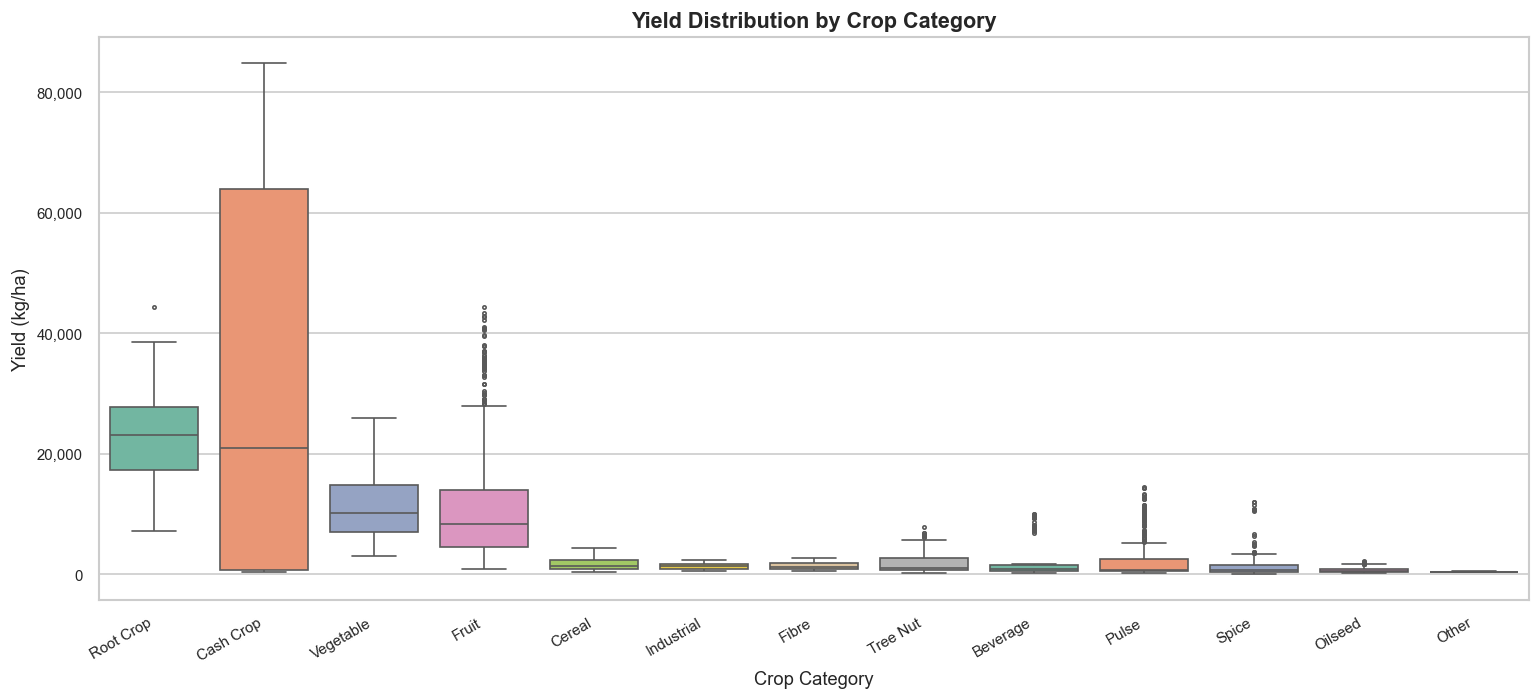

Saved: plot_02_yield_by_category.png


In [13]:
fig, ax = plt.subplots(figsize=(13, 6))
cat_order = df.groupby('crop_category')['yield_kg_ha'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='crop_category', y='yield_kg_ha', order=cat_order,
            palette='Set2', ax=ax, fliersize=2)
ax.set_title('Yield Distribution by Crop Category', fontweight='bold')
ax.set_xlabel('Crop Category')
ax.set_ylabel('Yield (kg/ha)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('plot_02_yield_by_category.png', bbox_inches='tight')
plt.show()
print("Saved: plot_02_yield_by_category.png")

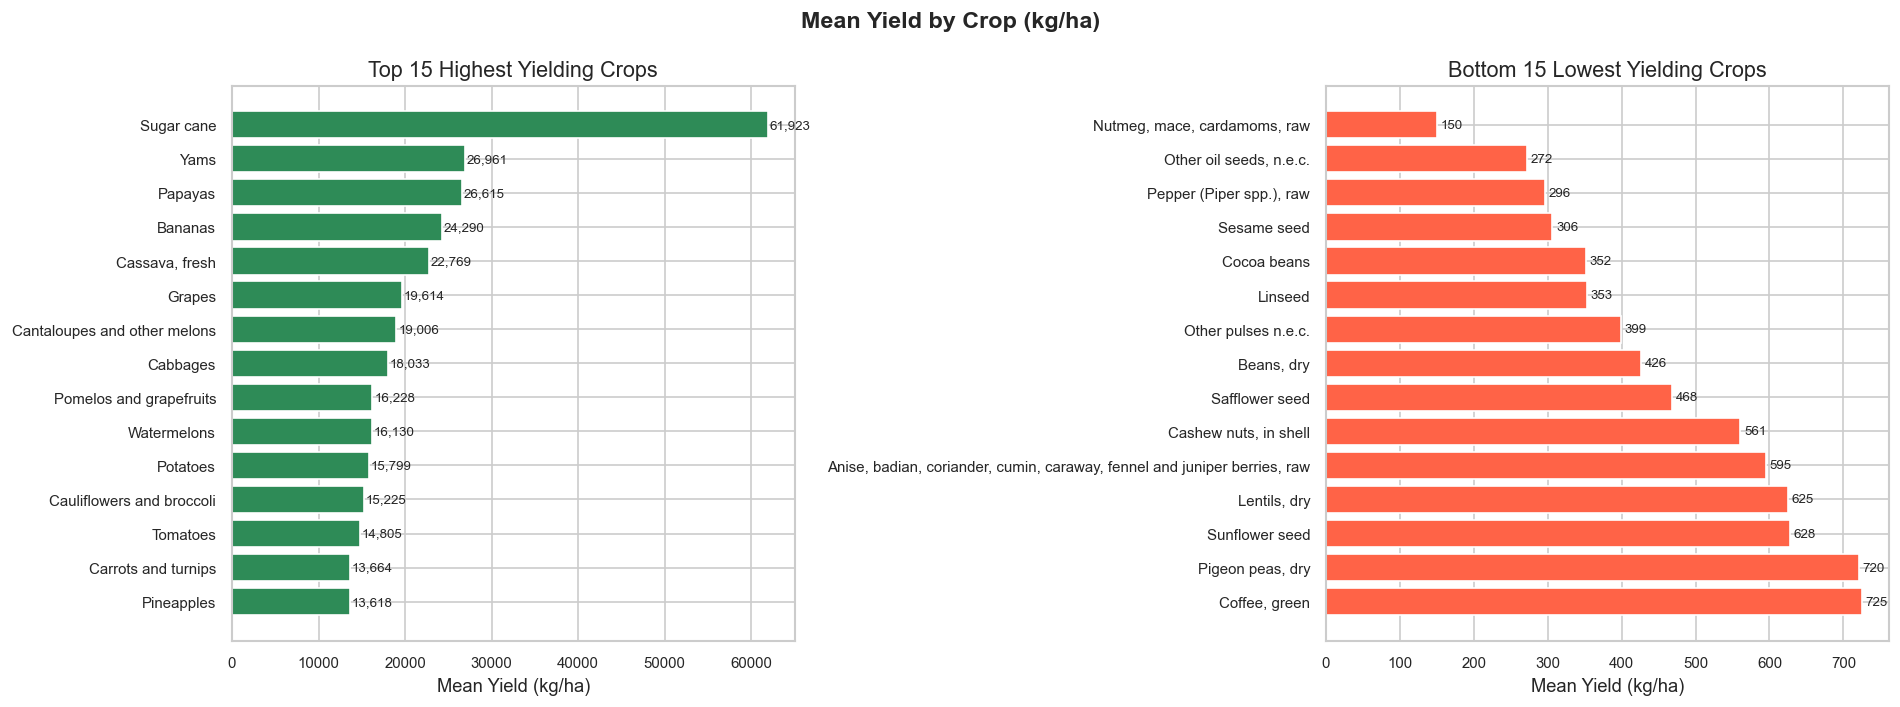

Saved: plot_03_top_bottom_crops.png


In [14]:
mean_yield = df.groupby('crop')['yield_kg_ha'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Mean Yield by Crop (kg/ha)', fontsize=14, fontweight='bold')

# Top 15
top15 = mean_yield.head(15)
axes[0].barh(top15.index[::-1], top15.values[::-1], color='seagreen', edgecolor='white')
axes[0].set_title('Top 15 Highest Yielding Crops')
axes[0].set_xlabel('Mean Yield (kg/ha)')
for i, v in enumerate(top15.values[::-1]):
    axes[0].text(v + 200, i, f'{v:,.0f}', va='center', fontsize=8)

# Bottom 15
bot15 = mean_yield.tail(15)
axes[1].barh(bot15.index, bot15.values, color='tomato', edgecolor='white')
axes[1].set_title('Bottom 15 Lowest Yielding Crops')
axes[1].set_xlabel('Mean Yield (kg/ha)')
for i, v in enumerate(bot15.values):
    axes[1].text(v + 5, i, f'{v:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('plot_03_top_bottom_crops.png', bbox_inches='tight')
plt.show()
print("Saved: plot_03_top_bottom_crops.png")

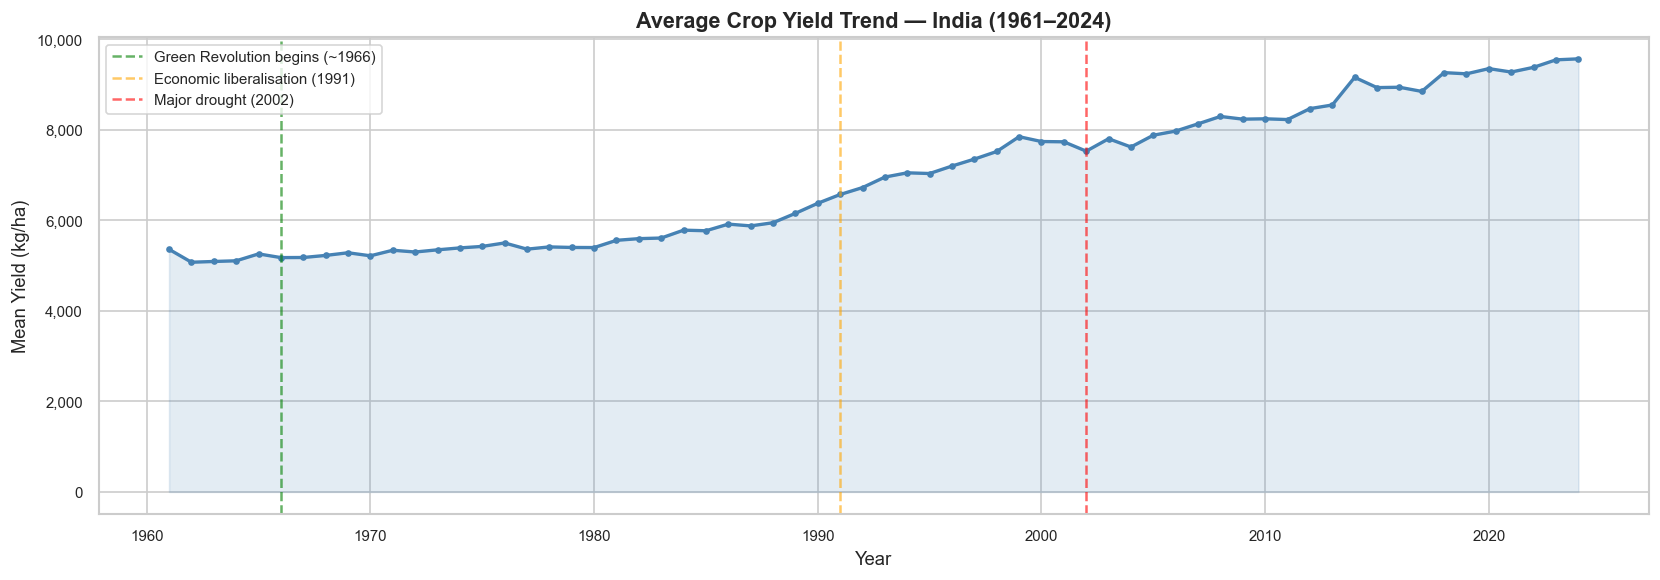

Saved: plot_04_yield_trend.png


In [15]:
yearly_yield = df.groupby('year')['yield_kg_ha'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(yearly_yield['year'], yearly_yield['yield_kg_ha'],
        color='steelblue', linewidth=2, marker='o', markersize=3)
ax.fill_between(yearly_yield['year'], yearly_yield['yield_kg_ha'],
                alpha=0.15, color='steelblue')
ax.set_title('Average Crop Yield Trend — India (1961–2024)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Yield (kg/ha)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
# Mark key events
ax.axvline(1966, color='green',  linestyle='--', alpha=0.6, label='Green Revolution begins (~1966)')
ax.axvline(1991, color='orange', linestyle='--', alpha=0.6, label='Economic liberalisation (1991)')
ax.axvline(2002, color='red',    linestyle='--', alpha=0.6, label='Major drought (2002)')
ax.legend()
plt.tight_layout()
plt.savefig('plot_04_yield_trend.png', bbox_inches='tight')
plt.show()
print("Saved: plot_04_yield_trend.png")

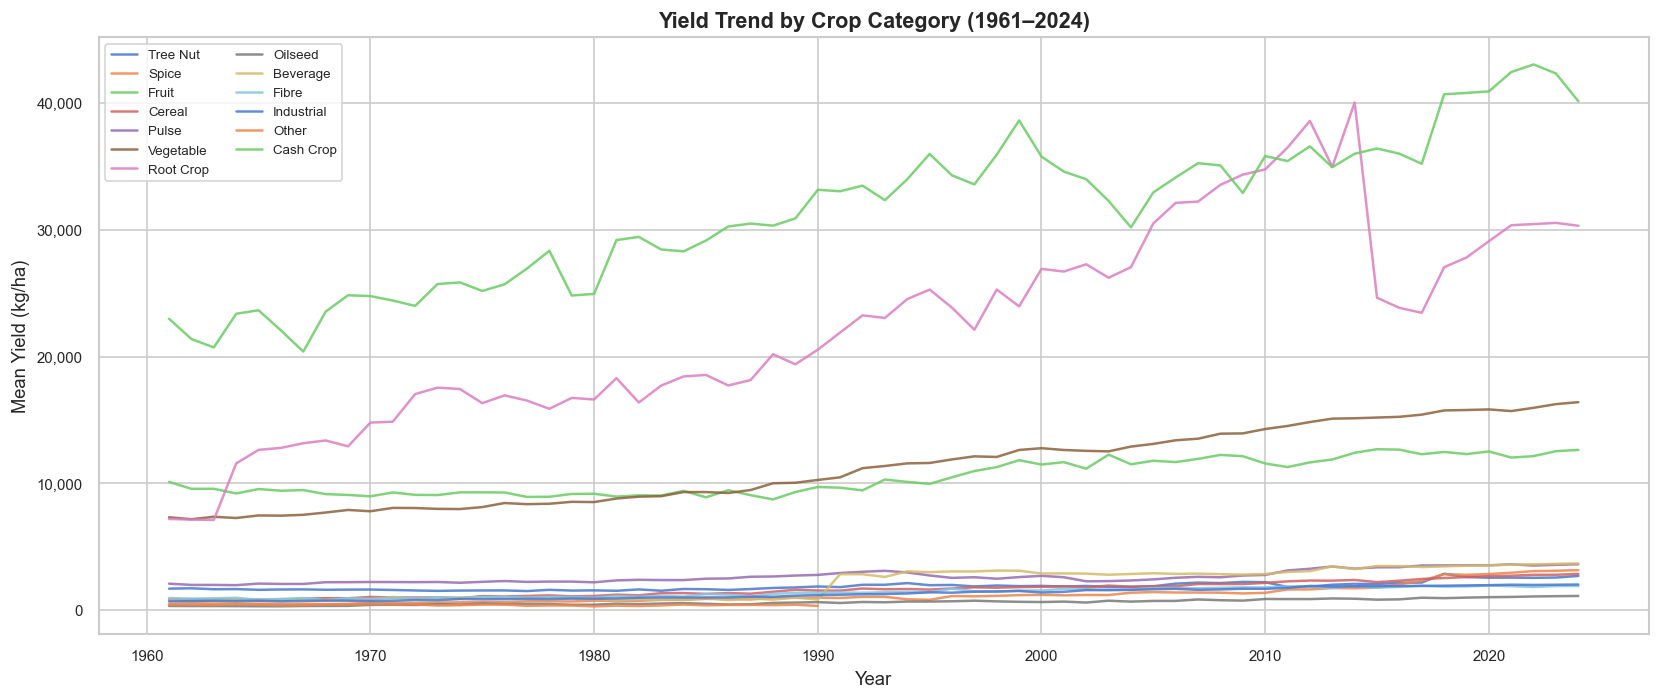

Saved: plot_05_yield_trend_by_category.png


In [16]:
fig, ax = plt.subplots(figsize=(14, 6))
cat_yearly = df.groupby(['year', 'crop_category'])['yield_kg_ha'].mean().reset_index()
for cat in df['crop_category'].unique():
    sub = cat_yearly[cat_yearly['crop_category'] == cat]
    ax.plot(sub['year'], sub['yield_kg_ha'], linewidth=1.5, label=cat, marker='', alpha=0.85)
ax.set_title('Yield Trend by Crop Category (1961–2024)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Yield (kg/ha)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(loc='upper left', ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig('plot_05_yield_trend_by_category.png', bbox_inches='tight')
plt.show()
print("Saved: plot_05_yield_trend_by_category.png")


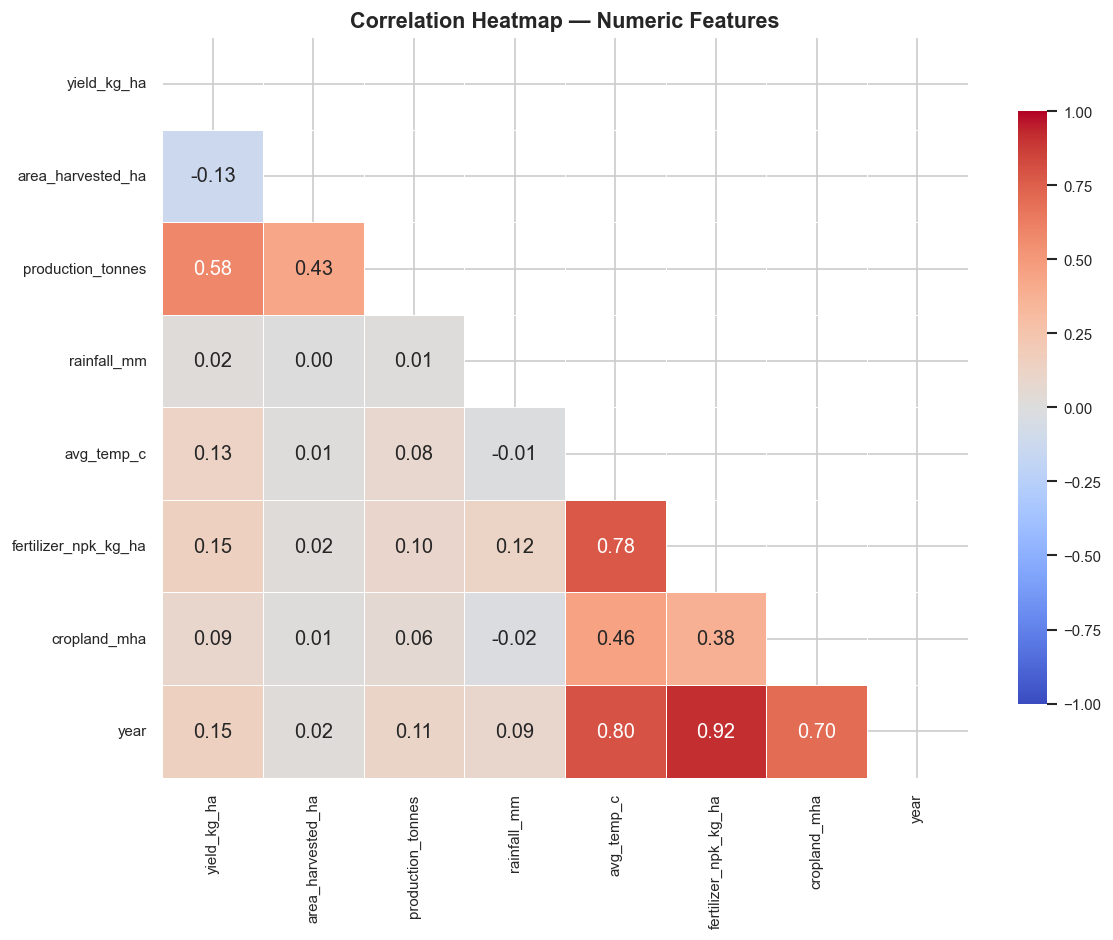

Saved: plot_06_correlation_heatmap.png

── Correlation with yield_kg_ha ──
yield_kg_ha             1.00
production_tonnes       0.58
fertilizer_npk_kg_ha    0.15
year                    0.15
avg_temp_c              0.13
cropland_mha            0.09
rainfall_mm             0.02
area_harvested_ha      -0.13


In [17]:
numeric_cols = ['yield_kg_ha', 'area_harvested_ha', 'production_tonnes',
                'rainfall_mm', 'avg_temp_c', 'fertilizer_npk_kg_ha',
                'cropland_mha', 'year']

corr = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_06_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved: plot_06_correlation_heatmap.png")

# Print top correlations with yield
print("\n── Correlation with yield_kg_ha ──")
print(corr['yield_kg_ha'].sort_values(ascending=False).to_string())

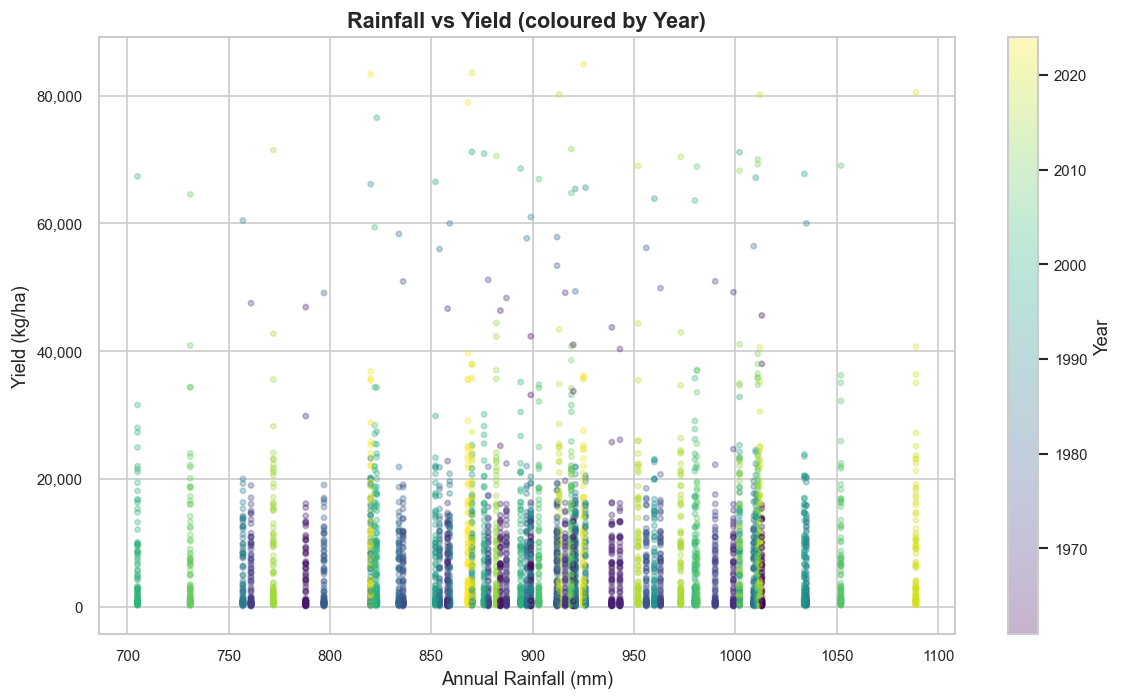

Saved: plot_07_rainfall_vs_yield.png


In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df['rainfall_mm'], df['yield_kg_ha'],
                     alpha=0.3, s=10, c=df['year'], cmap='viridis')
plt.colorbar(scatter, ax=ax, label='Year')
ax.set_title('Rainfall vs Yield (coloured by Year)', fontweight='bold')
ax.set_xlabel('Annual Rainfall (mm)')
ax.set_ylabel('Yield (kg/ha)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('plot_07_rainfall_vs_yield.png', bbox_inches='tight')
plt.show()
print("Saved: plot_07_rainfall_vs_yield.png")

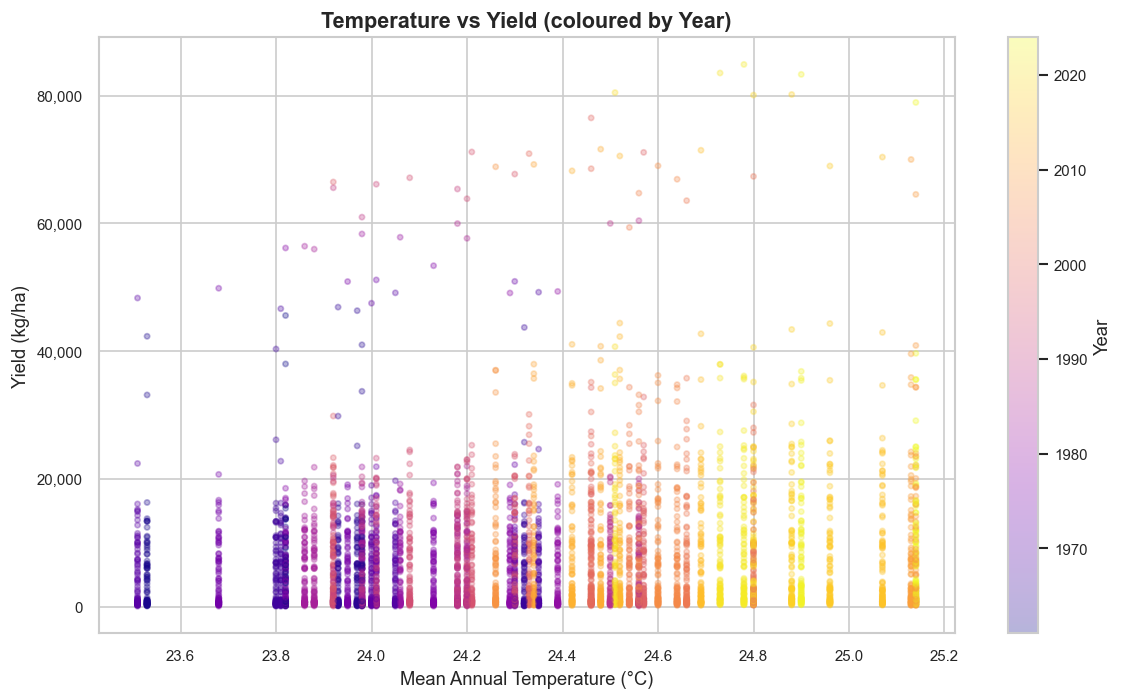

Saved: plot_08_temp_vs_yield.png


In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter2 = ax.scatter(df['avg_temp_c'], df['yield_kg_ha'],
                      alpha=0.3, s=10, c=df['year'], cmap='plasma')
plt.colorbar(scatter2, ax=ax, label='Year')
ax.set_title('Temperature vs Yield (coloured by Year)', fontweight='bold')
ax.set_xlabel('Mean Annual Temperature (°C)')
ax.set_ylabel('Yield (kg/ha)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('plot_08_temp_vs_yield.png', bbox_inches='tight')
plt.show()
print("Saved: plot_08_temp_vs_yield.png")

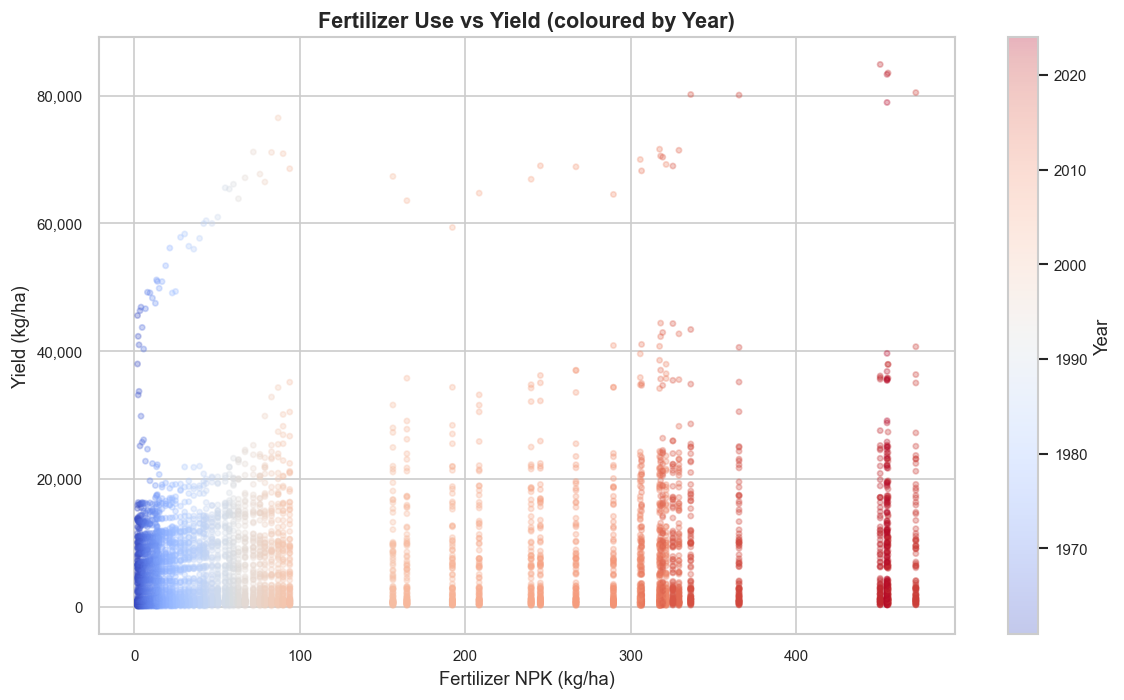

 Saved: plot_09_fertilizer_vs_yield.png


In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter3 = ax.scatter(df['fertilizer_npk_kg_ha'], df['yield_kg_ha'],
                      alpha=0.3, s=10, c=df['year'], cmap='coolwarm')
plt.colorbar(scatter3, ax=ax, label='Year')
ax.set_title('Fertilizer Use vs Yield (coloured by Year)', fontweight='bold')
ax.set_xlabel('Fertilizer NPK (kg/ha)')
ax.set_ylabel('Yield (kg/ha)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('plot_09_fertilizer_vs_yield.png', bbox_inches='tight')
plt.show()
print(" Saved: plot_09_fertilizer_vs_yield.png")

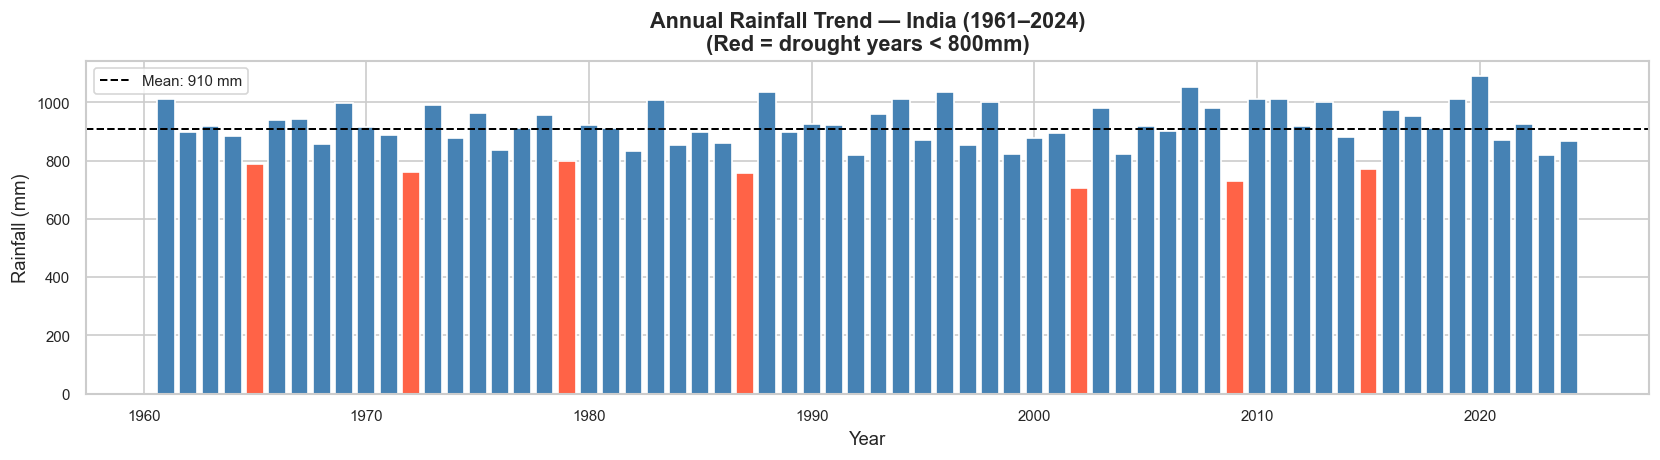

Saved: plot_10_rainfall_trend.png


In [21]:
yearly_rain = df.groupby('year')['rainfall_mm'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(yearly_rain['year'], yearly_rain['rainfall_mm'],
       color=['tomato' if v < 800 else 'steelblue' for v in yearly_rain['rainfall_mm']],
       edgecolor='white', width=0.8)
ax.axhline(yearly_rain['rainfall_mm'].mean(), color='black',
           linestyle='--', linewidth=1.2, label=f"Mean: {yearly_rain['rainfall_mm'].mean():.0f} mm")
ax.set_title('Annual Rainfall Trend — India (1961–2024)\n(Red = drought years < 800mm)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Rainfall (mm)')
ax.legend()
plt.tight_layout()
plt.savefig('plot_10_rainfall_trend.png', bbox_inches='tight')
plt.show()
print("Saved: plot_10_rainfall_trend.png")

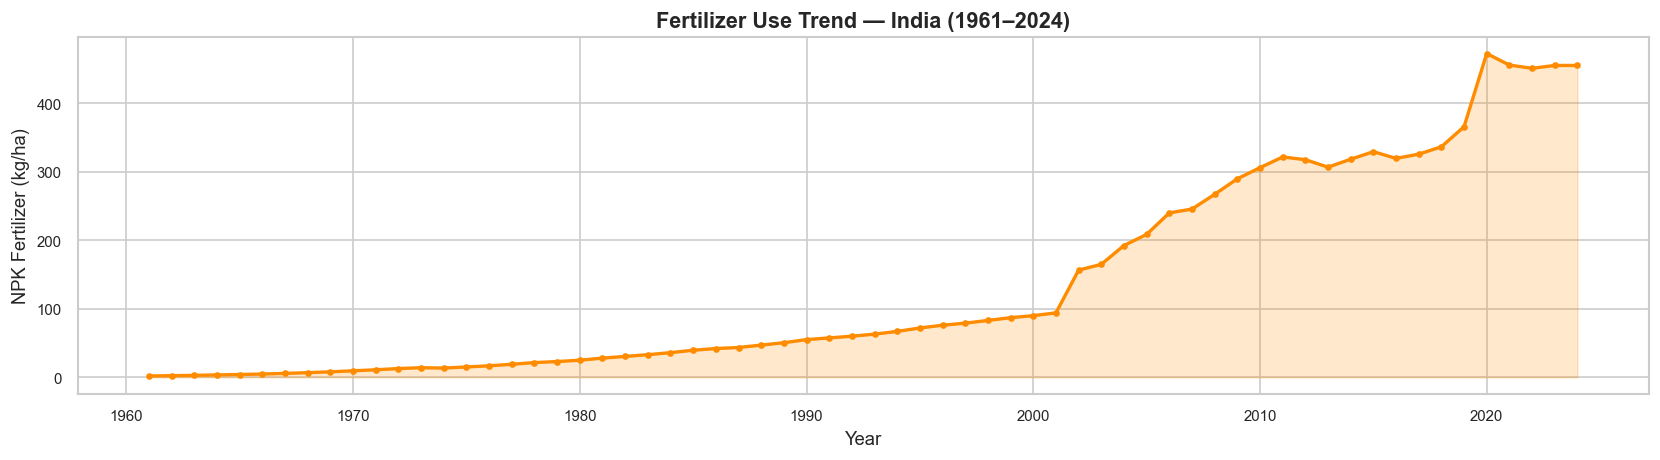

Saved: plot_11_fertilizer_trend.png


In [22]:
yearly_fert = df.groupby('year')['fertilizer_npk_kg_ha'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(yearly_fert['year'], yearly_fert['fertilizer_npk_kg_ha'],
        color='darkorange', linewidth=2, marker='o', markersize=3)
ax.fill_between(yearly_fert['year'], yearly_fert['fertilizer_npk_kg_ha'],
                alpha=0.2, color='darkorange')
ax.set_title('Fertilizer Use Trend — India (1961–2024)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('NPK Fertilizer (kg/ha)')
plt.tight_layout()
plt.savefig('plot_11_fertilizer_trend.png', bbox_inches='tight')
plt.show()
print("Saved: plot_11_fertilizer_trend.png")

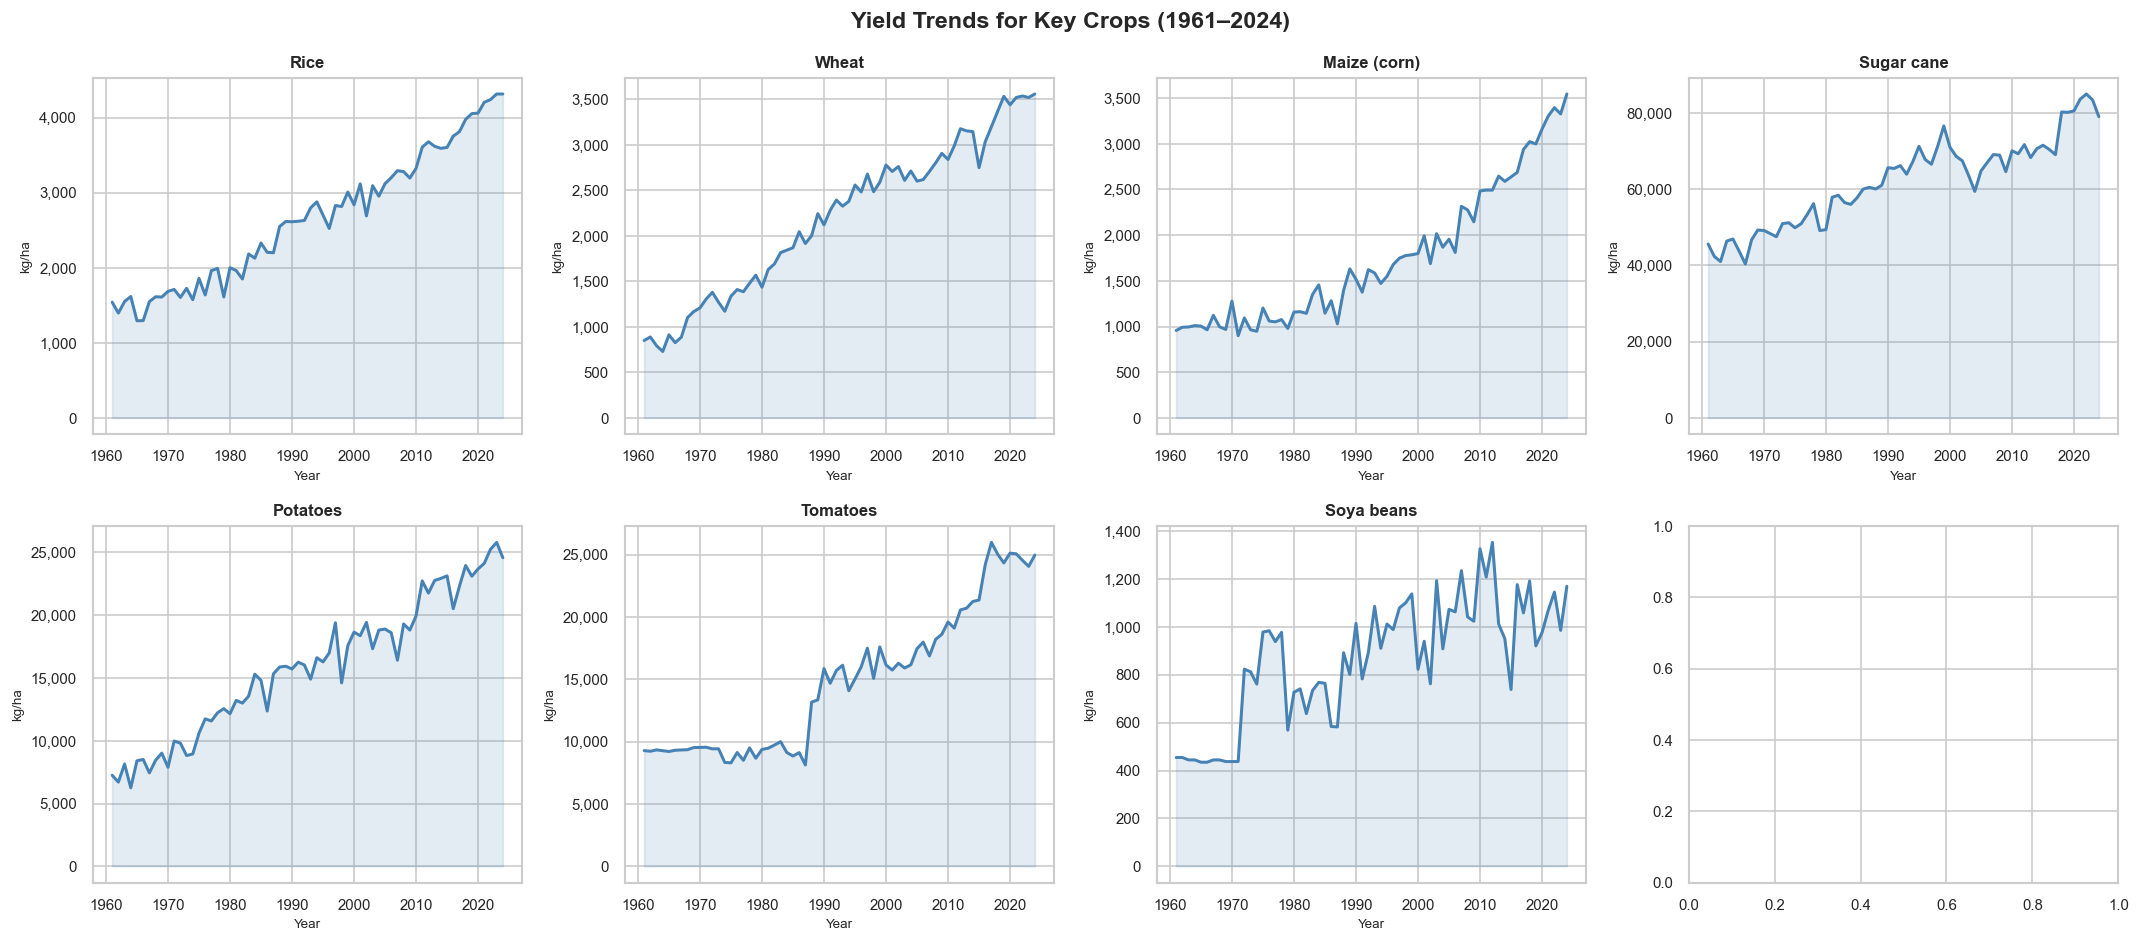

 Saved: plot_12_key_crops_trend.png


In [23]:
key_crops = ['Rice', 'Wheat', 'Maize (corn)', 'Sugar cane',
             'Potatoes', 'Tomatoes', 'Soya beans', 'Cotton']
# Filter to crops that exist in dataset
key_crops = [c for c in key_crops if c in df['crop'].unique()]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Yield Trends for Key Crops (1961–2024)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, crop in enumerate(key_crops[:8]):
    sub = df[df['crop'] == crop].groupby('year')['yield_kg_ha'].mean().reset_index()
    axes[i].plot(sub['year'], sub['yield_kg_ha'], color='steelblue', linewidth=1.8)
    axes[i].fill_between(sub['year'], sub['yield_kg_ha'], alpha=0.15, color='steelblue')
    axes[i].set_title(crop, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Year', fontsize=8)
    axes[i].set_ylabel('kg/ha', fontsize=8)
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('plot_12_key_crops_trend.png', bbox_inches='tight')
plt.show()
print(" Saved: plot_12_key_crops_trend.png")

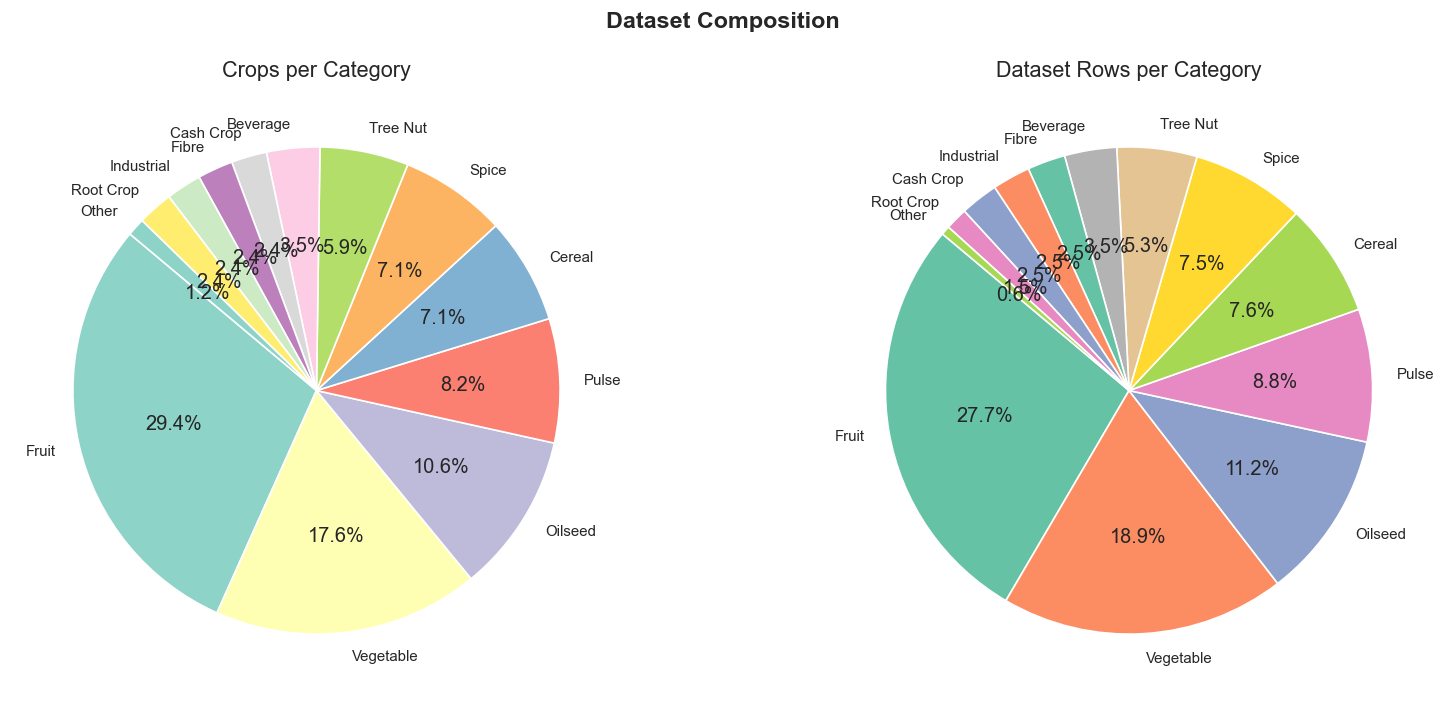

Saved: plot_13_category_distribution.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Dataset Composition', fontsize=14, fontweight='bold')

# Pie — number of crops per category
cat_crop_count = df.groupby('crop_category')['crop'].nunique().sort_values(ascending=False)
axes[0].pie(cat_crop_count.values, labels=cat_crop_count.index,
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Set3', len(cat_crop_count)))
axes[0].set_title('Crops per Category')

# Pie — rows per category
cat_row_count = df['crop_category'].value_counts()
axes[1].pie(cat_row_count.values, labels=cat_row_count.index,
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Set2', len(cat_row_count)))
axes[1].set_title('Dataset Rows per Category')

plt.tight_layout()
plt.savefig('plot_13_category_distribution.png', bbox_inches='tight')
plt.show()
print("Saved: plot_13_category_distribution.png")

In [25]:
print("\n── Outlier Summary (IQR method) ──")
Q1  = df['yield_kg_ha'].quantile(0.25)
Q3  = df['yield_kg_ha'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['yield_kg_ha'] < lower) | (df['yield_kg_ha'] > upper)]
print(f"  Q1          : {Q1:,.1f} kg/ha")
print(f"  Q3          : {Q3:,.1f} kg/ha")
print(f"  IQR         : {IQR:,.1f}")
print(f"  Lower bound : {lower:,.1f} kg/ha")
print(f"  Upper bound : {upper:,.1f} kg/ha")
print(f"  Outliers    : {len(outliers)} rows ({len(outliers)/len(df)*100:.1f}%)")
print("\n  Top 10 highest yield rows:")
print(df.nlargest(10, 'yield_kg_ha')[['crop', 'year', 'yield_kg_ha']].to_string(index=False))


── Outlier Summary (IQR method) ──
  Q1          : 826.1 kg/ha
  Q3          : 10,000.0 kg/ha
  IQR         : 9,173.9
  Lower bound : -12,934.7 kg/ha
  Upper bound : 23,760.8 kg/ha
  Outliers    : 204 rows (4.0%)

  Top 10 highest yield rows:
      crop  year  yield_kg_ha
Sugar cane  2022      84906.3
Sugar cane  2021      83566.2
Sugar cane  2023      83348.7
Sugar cane  2020      80496.6
Sugar cane  2018      80198.4
Sugar cane  2019      80104.5
Sugar cane  2024      78953.0
Sugar cane  1999      76532.8
Sugar cane  2012      71634.3
Sugar cane  2015      71466.1


In [26]:
print("\n" + "=" * 55)
print("  EDA COMPLETE — SUMMARY")
print("=" * 55)
print(f"  Total rows          : {len(df):,}")
print(f"  Total crops         : {df['crop'].nunique()}")
print(f"  Year range          : {df['year'].min()} – {df['year'].max()}")
print(f"  Missing values      : {df.isnull().sum().sum()}")
print(f"  Duplicate rows      : {df.duplicated().sum()}")
print(f"  Mean yield          : {df['yield_kg_ha'].mean():,.1f} kg/ha")
print(f"  Median yield        : {df['yield_kg_ha'].median():,.1f} kg/ha")
print(f"  Max yield           : {df['yield_kg_ha'].max():,.1f} kg/ha  ({df.loc[df['yield_kg_ha'].idxmax(), 'crop']})")
print(f"  Min yield           : {df['yield_kg_ha'].min():,.1f} kg/ha  ({df.loc[df['yield_kg_ha'].idxmin(), 'crop']})")
print(f"  Outliers (IQR)      : {len(outliers)} rows")
print(f"  Plots saved         : 13")
print("=" * 55)
3print("\nReady for preprocessing and model building!")


  EDA COMPLETE — SUMMARY
  Total rows          : 5,084
  Total crops         : 85
  Year range          : 1961 – 2024
  Missing values      : 0
  Duplicate rows      : 0
  Mean yield          : 6,954.7 kg/ha
  Median yield        : 3,082.7 kg/ha
  Max yield           : 84,906.3 kg/ha  (Sugar cane)
  Min yield           : 38.2 kg/ha  (Nutmeg, mace, cardamoms, raw)
  Outliers (IQR)      : 204 rows
  Plots saved         : 13

Ready for preprocessing and model building!


## 3. Data Preprocessing

- Missing values, duplicates, outlier check
- Feature engineering — `decade`, `log_area`, `rainfall_category`
- Label encode categorical features
- Exclude `production_tonnes` — mathematically linked to target (data leakage)
- Time-based split: Train 1961–2015 | Test 2016–2024
- StandardScaler for Linear Regression only

In [27]:

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

print("=" * 55)
print("  INDIA CROP YIELD — PREPROCESSING PIPELINE")


  INDIA CROP YIELD — PREPROCESSING PIPELINE


In [28]:
df_raw = df.copy()

In [29]:
print("\n── Data Types ──")
print(df.dtypes)


── Data Types ──
crop                     object
crop_category            object
year                      int64
area_harvested_ha       float64
production_tonnes       float64
rainfall_mm               int64
avg_temp_c              float64
fertilizer_npk_kg_ha    float64
cropland_mha            float64
yield_kg_ha             float64
dtype: object


In [30]:
print("\n── Missing Values ──")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found")


── Missing Values ──
No missing values found


In [31]:
dupes = df.duplicated().sum()
print(f"\n── Duplicates: {dupes} ──")
if dupes > 0:
    df = df.drop_duplicates()
    print(f"  Dropped {dupes} duplicate rows")
else:
    print("No duplicates found")


── Duplicates: 0 ──
No duplicates found


In [32]:
print("\n── Outlier Detection (IQR Method on yield_kg_ha) ──")

Q1  = df['yield_kg_ha'].quantile(0.25)
Q3  = df['yield_kg_ha'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['yield_kg_ha'] < lower) | (df['yield_kg_ha'] > upper)]
print(f"  Lower bound : {lower:,.1f} kg/ha")
print(f"  Upper bound : {upper:,.1f} kg/ha")
print(f"  Outliers    : {len(outliers)} rows ({len(outliers)/len(df)*100:.1f}%)")
print(f"\n  Top outlier crops:")
print(outliers.nlargest(10, 'yield_kg_ha')[['crop','year','yield_kg_ha']].to_string(index=False))

print("\nOutliers kept — they are real high-yield crops (e.g. Sugar cane)")
print("Tree-based models handle these naturally without removal")


── Outlier Detection (IQR Method on yield_kg_ha) ──
  Lower bound : -12,934.7 kg/ha
  Upper bound : 23,760.8 kg/ha
  Outliers    : 204 rows (4.0%)

  Top outlier crops:
      crop  year  yield_kg_ha
Sugar cane  2022      84906.3
Sugar cane  2021      83566.2
Sugar cane  2023      83348.7
Sugar cane  2020      80496.6
Sugar cane  2018      80198.4
Sugar cane  2019      80104.5
Sugar cane  2024      78953.0
Sugar cane  1999      76532.8
Sugar cane  2012      71634.3
Sugar cane  2015      71466.1

Outliers kept — they are real high-yield crops (e.g. Sugar cane)
Tree-based models handle these naturally without removal


In [ ]:
print("\n── Feature Engineering ──")

#Decade column useful for the model to learn era-based patterns
df['decade'] = (df['year'] // 10) * 10
print("Added: decade (1960, 1970, ... 2020)")

#log_area: area_harvested_ha is highly skewed, log transform helps
df['log_area'] = np.log1p(df['area_harvested_ha'])
print("Added: log_area = log(area_harvested_ha + 1)")

#log_production: same reason
df['log_production'] = np.log1p(df['production_tonnes'])
print("Added: log_production = log(production_tonnes + 1)")

#Rainfall-category: dry / normal / wet year
df['rainfall_category'] = pd.cut(
    df['rainfall_mm'],
    bins=[0, 800, 950, 1100, 9999],
    labels=['Drought', 'Below Normal', 'Normal', 'Above Normal']
)
print("Added: rainfall_category (Drought / Below Normal / Normal / Above Normal)")

print(f"\n  Rainfall category breakdown:")
print(df['rainfall_category'].value_counts().to_string())


── Feature Engineering ──
Added: decade (1960, 1970, ... 2020)
Added: log_area = log(area_harvested_ha + 1)
Added: log_production = log(production_tonnes + 1)
Added: rainfall_category (Drought / Below Normal / Normal / Above Normal)

  Rainfall category breakdown:
rainfall_category
Below Normal    2852
Normal          1677
Drought          555
Above Normal       0


In [34]:
print("\n── Encoding Categorical Features ──")

le_crop     = LabelEncoder()
le_category = LabelEncoder()
le_rain_cat = LabelEncoder()

df['crop_encoded']             = le_crop.fit_transform(df['crop'])
df['crop_category_encoded']    = le_category.fit_transform(df['crop_category'])
df['rainfall_category_encoded']= le_rain_cat.fit_transform(df['rainfall_category'].astype(str))

print("Label Encoded: crop → crop_encoded")
print("Label Encoded: crop_category → crop_category_encoded")
print("Label Encoded: rainfall_category → rainfall_category_encoded")

# Show the encoding mappings
print("\n  Crop Category Encoding Map:")
for i, cls in enumerate(le_category.classes_):
    print(f"    {i} → {cls}")

print("\n  Rainfall Category Encoding Map:")
for i, cls in enumerate(le_rain_cat.classes_):
    print(f"    {i} → {cls}")


── Encoding Categorical Features ──
Label Encoded: crop → crop_encoded
Label Encoded: crop_category → crop_category_encoded
Label Encoded: rainfall_category → rainfall_category_encoded

  Crop Category Encoding Map:
    0 → Beverage
    1 → Cash Crop
    2 → Cereal
    3 → Fibre
    4 → Fruit
    5 → Industrial
    6 → Oilseed
    7 → Other
    8 → Pulse
    9 → Root Crop
    10 → Spice
    11 → Tree Nut
    12 → Vegetable

  Rainfall Category Encoding Map:
    0 → Below Normal
    1 → Drought
    2 → Normal


In [35]:
print("\n── Defining Feature Set ──")

# Features for tree-based models (RF, XGBoost, Decision Tree)
# No scaling needed for these
FEATURES_TREE = [
    'crop_encoded',             # which crop
    'crop_category_encoded',    # which category
    'year',                     # technology trend
    'decade',                   # era-level pattern
    'area_harvested_ha',        # scale of farming
    'log_area',                 # log-transformed area
    'production_tonnes',        # total production
    'log_production',           # log-transformed production
    'rainfall_mm',              # climate
    'rainfall_category_encoded',# drought/normal/wet signal
    'avg_temp_c',               # temperature
    'fertilizer_npk_kg_ha',     # input intensity
    'cropland_mha',             # national land context
]

# Features for linear models (Linear Regression)
# These need scaling
FEATURES_LINEAR = FEATURES_TREE.copy()

TARGET = 'yield_kg_ha'

print(f"\n  Total features : {len(FEATURES_TREE)}")
for f in FEATURES_TREE:
    print(f"    ✔ {f}")
print(f"\n  Target         : {TARGET}")


── Defining Feature Set ──

  Total features : 13
    ✔ crop_encoded
    ✔ crop_category_encoded
    ✔ year
    ✔ decade
    ✔ area_harvested_ha
    ✔ log_area
    ✔ production_tonnes
    ✔ log_production
    ✔ rainfall_mm
    ✔ rainfall_category_encoded
    ✔ avg_temp_c
    ✔ fertilizer_npk_kg_ha
    ✔ cropland_mha

  Target         : yield_kg_ha


In [36]:
print("\n── Preparing X and y ──")

X = df[FEATURES_TREE]
y = df[TARGET]

print(f"  X shape : {X.shape}")
print(f"  y shape : {y.shape}")
print(f"  y range : {y.min():,.1f} – {y.max():,.1f} kg/ha")
print(f"  y mean  : {y.mean():,.1f} kg/ha")


── Preparing X and y ──
  X shape : (5084, 13)
  y shape : (5084,)
  y range : 38.2 – 84,906.3 kg/ha
  y mean  : 6,954.7 kg/ha


In [37]:
print("\n── Train / Test Split (80/20) ──")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"  Training set : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set     : {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(X)*100:.1f}%)")


── Train / Test Split (80/20) ──
  Training set : 4,067 rows (80.0%)
  Test set     : 1,017 rows  (20.0%)


In [38]:
print("\n── Feature Scaling (StandardScaler — for Linear Regression only) ──")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)         # transform test with same scaler

X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURES_LINEAR)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=FEATURES_LINEAR)

print("StandardScaler fitted on training set")
print("Applied to test set using training parameters")
print("Note: scaler.fit() only on X_train — never on X_test (prevents data leakage)")


── Feature Scaling (StandardScaler — for Linear Regression only) ──
StandardScaler fitted on training set
Applied to test set using training parameters
Note: scaler.fit() only on X_train — never on X_test (prevents data leakage)


In [39]:
print("\n── Final Shape Summary ──")
print(f"  X_train        : {X_train.shape}")
print(f"  X_test         : {X_test.shape}")
print(f"  y_train        : {y_train.shape}")
print(f"  y_test         : {y_test.shape}")
print(f"  X_train_scaled : {X_train_scaled.shape}")
print(f"  X_test_scaled  : {X_test_scaled.shape}")


── Final Shape Summary ──
  X_train        : (4067, 13)
  X_test         : (1017, 13)
  y_train        : (4067,)
  y_test         : (1017,)
  X_train_scaled : (4067, 13)
  X_test_scaled  : (1017, 13)


In [40]:
print("\n── Saving Preprocessed Files ──")

# Save the full preprocessed dataframe
df_preprocessed = df[FEATURES_TREE + [TARGET]].copy()
df_preprocessed.to_csv('india_yield_preprocessed.csv', index=False)
print("Saved: india_yield_preprocessed.csv")

# Save train/test splits
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv',   index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv',   index=False)
print("Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv")


── Saving Preprocessed Files ──
Saved: india_yield_preprocessed.csv
Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv


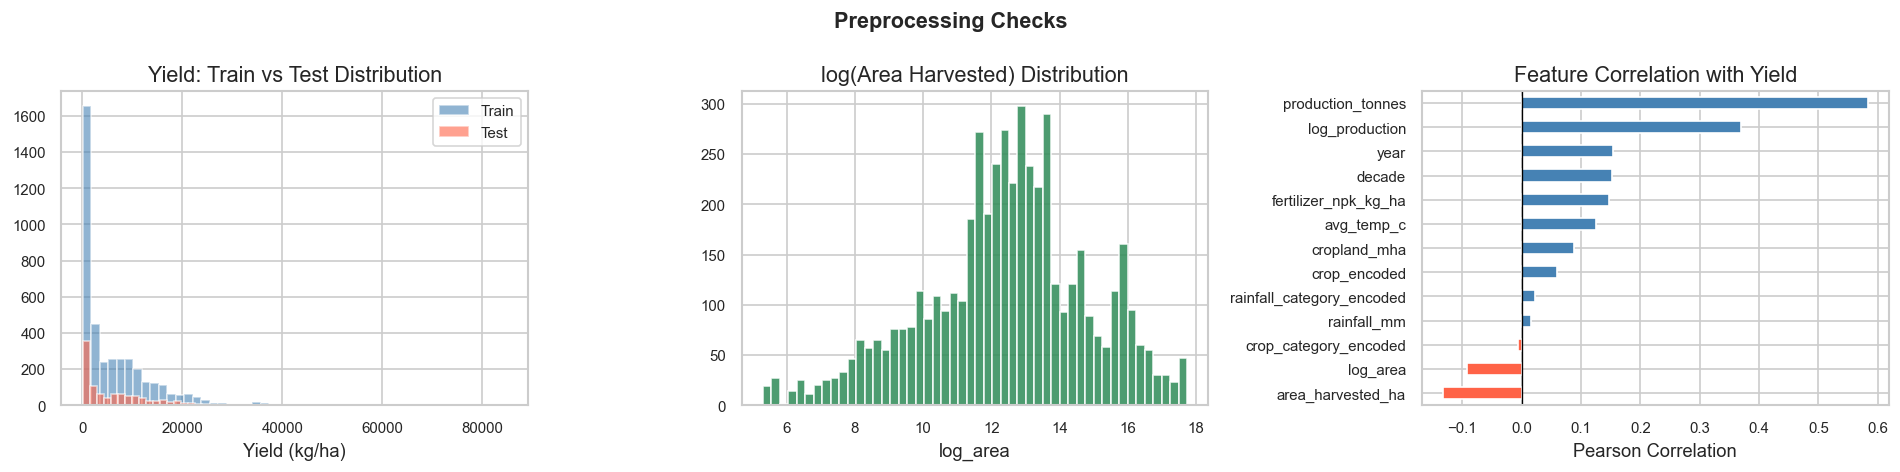


Saved: plot_preprocessing_checks.png


In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Preprocessing Checks', fontsize=13, fontweight='bold')

# Train vs test yield distribution
axes[0].hist(y_train, bins=50, alpha=0.6, color='steelblue', label='Train')
axes[0].hist(y_test,  bins=50, alpha=0.6, color='tomato',    label='Test')
axes[0].set_title('Yield: Train vs Test Distribution')
axes[0].set_xlabel('Yield (kg/ha)')
axes[0].legend()

# log_area distribution
axes[1].hist(df['log_area'], bins=50, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('log(Area Harvested) Distribution')
axes[1].set_xlabel('log_area')

# Feature correlation with target
feat_corr = df[FEATURES_TREE + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
feat_corr.plot(kind='barh', ax=axes[2], color=[
    'tomato' if v < 0 else 'steelblue' for v in feat_corr.values
])
axes[2].set_title('Feature Correlation with Yield')
axes[2].set_xlabel('Pearson Correlation')
axes[2].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('plot_preprocessing_checks.png', bbox_inches='tight')
plt.show()
print("\nSaved: plot_preprocessing_checks.png")

In [42]:
print("\n" + "=" * 55)
print("  PREPROCESSING COMPLETE")
print("=" * 55)
print(f"  Original features     : 9")
print(f"  Engineered features   : 4 (decade, log_area, log_production, rainfall_category)")
print(f"  Final feature count   : {len(FEATURES_TREE)}")
print(f"  Training samples      : {X_train.shape[0]:,}")
print(f"  Test samples          : {X_test.shape[0]:,}")
print(f"  Scaling               : StandardScaler (for Linear Regression only)")
print(f"  Missing values        : 0")
print(f"  Outliers removed      : 0 (intentional — valid data)")
print("=" * 55)
print("\nReady for model building!")
print("\nVariables ready to use in next script:")
print("  X_train, X_test        → for tree models (RF, XGBoost, DT)")
print("  X_train_scaled,")
print("  X_test_scaled          → for Linear Regression")
print("  y_train, y_test        → target for all models")


  PREPROCESSING COMPLETE
  Original features     : 9
  Engineered features   : 4 (decade, log_area, log_production, rainfall_category)
  Final feature count   : 13
  Training samples      : 4,067
  Test samples          : 1,017
  Scaling               : StandardScaler (for Linear Regression only)
  Missing values        : 0
  Outliers removed      : 0 (intentional — valid data)

Ready for model building!

Variables ready to use in next script:
  X_train, X_test        → for tree models (RF, XGBoost, DT)
  X_train_scaled,
  X_test_scaled          → for Linear Regression
  y_train, y_test        → target for all models


## 4. Model Building & Evaluation

| Model | Type |
|---|---|
| Linear Regression | Baseline |
| Decision Tree | Depth-tuned |
| Random Forest | 300 trees |
| XGBoost | Best model |

> ⚠️ `production_tonnes` excluded from all models — data leakage risk.

In [74]:
from sklearn.linear_model    import LinearRegression
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor
from sklearn.metrics         import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from xgboost                 import XGBRegressor

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

print("-" * 60)
print("  INDIA CROP YIELD PREDICTION — MODEL BUILDING")
print("  (Leakage-free | Time-based split)")
print("-" * 60)

------------------------------------------------------------
  INDIA CROP YIELD PREDICTION — MODEL BUILDING
  (Leakage-free | Time-based split)
------------------------------------------------------------


In [75]:
print("\n── Loading Dataset ──")
df = pd.read_csv('india_yield_final_dataset.csv')
print(f"  Loaded : {df.shape[0]:,} rows × {df.shape[1]} columns")


── Loading Dataset ──
  Loaded : 5,084 rows × 10 columns


In [76]:
print("\n── Feature Engineering ──")

df['decade']   = (df['year'] // 10) * 10
df['log_area'] = np.log1p(df['area_harvested_ha'])
df['rainfall_category'] = pd.cut(
    df['rainfall_mm'],
    bins=[0, 800, 950, 1100, 9999],
    labels=['Drought', 'Below Normal', 'Normal', 'Above Normal']
)

le_crop = LabelEncoder()
le_cat  = LabelEncoder()
le_rain = LabelEncoder()
df['crop_encoded']              = le_crop.fit_transform(df['crop'])
df['crop_category_encoded']     = le_cat.fit_transform(df['crop_category'])
df['rainfall_category_encoded'] = le_rain.fit_transform(df['rainfall_category'].astype(str))

print("  decade, log_area, rainfall_category added")
print("  crop, crop_category, rainfall_category encoded")
print("  production_tonnes EXCLUDED — mathematically linked to target (leakage)")
print("  log_production    EXCLUDED — same reason")


── Feature Engineering ──
  decade, log_area, rainfall_category added
  crop, crop_category, rainfall_category encoded
  production_tonnes EXCLUDED — mathematically linked to target (leakage)
  log_production    EXCLUDED — same reason


In [77]:
FEATURES = [
    'crop_encoded',              # which crop
    'crop_category_encoded',     # which category
    'year',                      # technology/trend signal
    'decade',                    # era-level pattern
    'area_harvested_ha',         # scale of cultivation
    'log_area',                  # log-transformed area (handles skew)
    'rainfall_mm',               # annual rainfall
    'rainfall_category_encoded', # drought/normal/wet signal
    'avg_temp_c',                # mean annual temperature
    'fertilizer_npk_kg_ha',      # fertilizer input
    'cropland_mha',              # national cropland context
]

TARGET = 'yield_kg_ha'

print(f"\n  Final feature count : {len(FEATURES)}")
for f in FEATURES:
    print(f"    ✔ {f}")
print(f"  Target : {TARGET}")



  Final feature count : 11
    ✔ crop_encoded
    ✔ crop_category_encoded
    ✔ year
    ✔ decade
    ✔ area_harvested_ha
    ✔ log_area
    ✔ rainfall_mm
    ✔ rainfall_category_encoded
    ✔ avg_temp_c
    ✔ fertilizer_npk_kg_ha
    ✔ cropland_mha
  Target : yield_kg_ha


In [78]:
print("\n── Time-Based Train/Test Split ──")
print("  Train : 1961–2015  |  Test : 2016–2024")
print("  (Simulates real-world: model trained on past, tested on future)")

train_df = df[df['year'] <= 2015]
test_df  = df[df['year'] >  2015]

X_train = train_df[FEATURES]
X_test  = test_df[FEATURES]
y_train = train_df[TARGET]
y_test  = test_df[TARGET]

print(f"\n  Training set : {len(X_train):,} rows ({train_df['year'].min()}–{train_df['year'].max()})")
print(f"  Test set     : {len(X_test):,} rows  ({test_df['year'].min()}–{test_df['year'].max()})")


── Time-Based Train/Test Split ──
  Train : 1961–2015  |  Test : 2016–2024
  (Simulates real-world: model trained on past, tested on future)

  Training set : 4,336 rows (1961–2015)
  Test set     : 748 rows  (2016–2024)


In [79]:

# Full data for cross validation
X_full = df[FEATURES]
y_full = df[TARGET]

# Scaling for Linear Regression only
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
X_full_sc  = StandardScaler().fit_transform(X_full)



In [80]:
def evaluate(name, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"\n  {'─'*45}")
    print(f"  Model : {name}")
    print(f"  R²    : {r2:.4f}  {'Excellent' if r2>0.85 else (' Good' if r2>0.70 else 'Weak')}")
    print(f"  MAE   : {mae:,.1f} kg/ha")
    print(f"  RMSE  : {rmse:,.1f} kg/ha")
    return {'Model': name, 'R²': round(r2,4), 'MAE': round(mae,1), 'RMSE': round(rmse,1)}

results = []

### 4.1 Linear Regression — Baseline

In [106]:
print("\n\n" + "-"*60)
print("  MODEL 1 — LINEAR REGRESSION (Baseline)")
print("-"*60)

lr = LinearRegression()
lr.fit(X_train_sc, y_train)
pred_lr = np.clip(lr.predict(X_test_sc), 0, None)
results.append(evaluate("Linear Regression", y_test, pred_lr))



------------------------------------------------------------
  MODEL 1 — LINEAR REGRESSION (Baseline)
------------------------------------------------------------

  ─────────────────────────────────────────────
  Model : Linear Regression
  R²    : 0.0101  Weak
  MAE   : 8,139.3 kg/ha
  RMSE  : 11,791.1 kg/ha


In [107]:
cv_lr = cross_val_score(lr, X_full_sc, y_full, cv=5, scoring='r2')
print(f"  5-Fold CV R² : {cv_lr.mean():.4f} ± {cv_lr.std():.4f}")

  5-Fold CV R² : -0.1335 ± 0.1014


In [108]:
coef_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': lr.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
print("\n  Top 5 influential features (by coefficient):")
print(coef_df.head(5).to_string(index=False))


  Top 5 influential features (by coefficient):
          Feature  Coefficient
             year  2678.521791
area_harvested_ha -1106.374536
     cropland_mha  -875.993905
     crop_encoded   735.176560
         log_area  -732.742870


### 4.2 Decision Tree


In [105]:
print("\n\n" + "-"*60)
print("  MODEL 2 — DECISION TREE")
print("-"*60)

print("\n  Tuning max_depth (3–20)...")
depth_scores = {}
for depth in range(3, 21):
    dt_tmp = DecisionTreeRegressor(max_depth=depth, random_state=42)
    depth_scores[depth] = cross_val_score(
        dt_tmp, X_train, y_train, cv=5, scoring='r2').mean()

best_depth = max(depth_scores, key=depth_scores.get)
print(f"  Best max_depth : {best_depth}  (CV R² = {depth_scores[best_depth]:.4f})")



------------------------------------------------------------
  MODEL 2 — DECISION TREE
------------------------------------------------------------

  Tuning max_depth (3–20)...
  Best max_depth : 7  (CV R² = 0.2398)


In [83]:

dt = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
results.append(evaluate("Decision Tree", y_test, pred_dt))

cv_dt = cross_val_score(dt, X_full, y_full, cv=5, scoring='r2')
print(f"  5-Fold CV R² : {cv_dt.mean():.4f} ± {cv_dt.std():.4f}")



  ─────────────────────────────────────────────
  Model : Decision Tree
  R²    : 0.5740  Weak
  MAE   : 3,628.8 kg/ha
  RMSE  : 7,734.8 kg/ha
  5-Fold CV R² : -0.3004 ± 0.9938


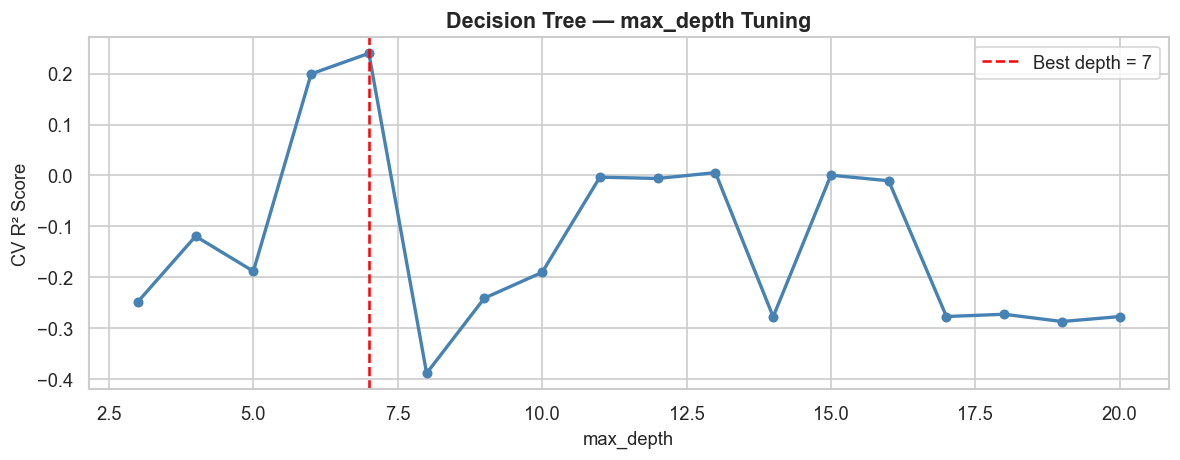

In [109]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(depth_scores.keys()), list(depth_scores.values()),
        marker='o', color='steelblue', linewidth=2, markersize=5)
ax.axvline(best_depth, color='red', linestyle='--', label=f'Best depth = {best_depth}')
ax.set_title('Decision Tree — max_depth Tuning', fontweight='bold')
ax.set_xlabel('max_depth'); ax.set_ylabel('CV R² Score')
ax.legend(); plt.tight_layout()
plt.show()

### 4.3 Random Forest


In [110]:
print("\n\n" + "-"*60)
print("  MODEL 3 — RANDOM FOREST")
print("-"*60)

rf = RandomForestRegressor(
    n_estimators=300, max_depth=None,
    min_samples_split=2, min_samples_leaf=1,
    random_state=42, n_jobs=-1
)
print("\n  Training Random Forest (300 trees)... please wait")
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
results.append(evaluate("Random Forest", y_test, pred_rf))




------------------------------------------------------------
  MODEL 3 — RANDOM FOREST
------------------------------------------------------------

  Training Random Forest (300 trees)... please wait

  ─────────────────────────────────────────────
  Model : Random Forest
  R²    : 0.8653  Excellent
  MAE   : 1,792.7 kg/ha
  RMSE  : 4,349.5 kg/ha


In [86]:
cv_rf = cross_val_score(rf, X_full, y_full, cv=5, scoring='r2', n_jobs=-1)
print(f"  5-Fold CV R² : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")

rf_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("\n  Feature Importances:")
print(rf_imp.to_string())

  5-Fold CV R² : 0.0593 ± 0.2980

  Feature Importances:
crop_encoded                 0.379622
crop_category_encoded        0.286870
log_area                     0.136104
area_harvested_ha            0.129644
fertilizer_npk_kg_ha         0.026736
year                         0.024870
cropland_mha                 0.008680
decade                       0.004529
avg_temp_c                   0.001564
rainfall_mm                  0.001181
rainfall_category_encoded    0.000201


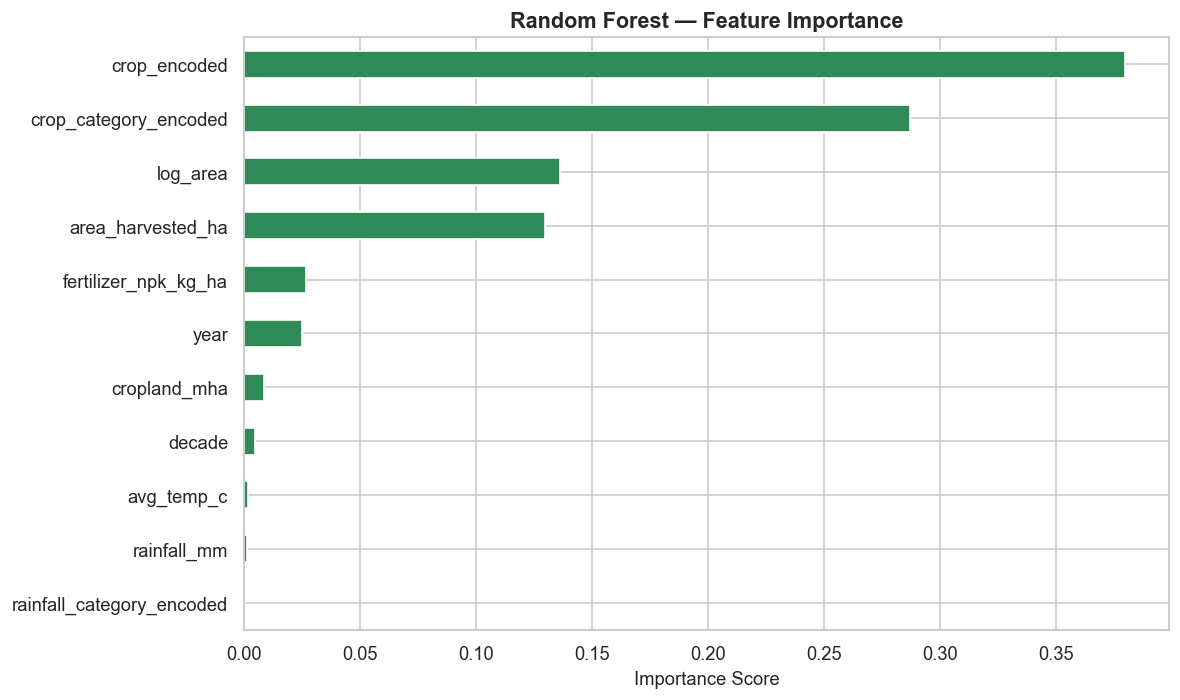

In [111]:
fig, ax = plt.subplots(figsize=(10, 6))
rf_imp.sort_values().plot(kind='barh', ax=ax, color='seagreen', edgecolor='white')
ax.set_title('Random Forest — Feature Importance', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

### 4.4 XGBoost


In [112]:
print("\n\n" + "-"*60)
print("  MODEL 4 — XGBOOST")
print("-"*60)

xgb = XGBRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=6, subsample=0.8,
    colsample_bytree=0.8, random_state=42,
    n_jobs=-1, verbosity=0
)
print("\n  Training XGBoost (300 estimators)... please wait")
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
pred_xgb = xgb.predict(X_test)
results.append(evaluate("XGBoost", y_test, pred_xgb))



------------------------------------------------------------
  MODEL 4 — XGBOOST
------------------------------------------------------------

  Training XGBoost (300 estimators)... please wait

  ─────────────────────────────────────────────
  Model : XGBoost
  R²    : 0.9032  Excellent
  MAE   : 1,859.0 kg/ha
  RMSE  : 3,686.9 kg/ha


In [89]:

cv_xgb = cross_val_score(xgb, X_full, y_full, cv=5, scoring='r2', n_jobs=-1)
print(f"  5-Fold CV R² : {cv_xgb.mean():.4f} ± {cv_xgb.std():.4f}")

xgb_imp = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("\n  Feature Importances:")
print(xgb_imp.to_string())

  5-Fold CV R² : 0.2983 ± 0.2463

  Feature Importances:
crop_category_encoded        0.515085
crop_encoded                 0.245345
area_harvested_ha            0.077969
log_area                     0.068171
year                         0.029945
fertilizer_npk_kg_ha         0.024701
decade                       0.021275
cropland_mha                 0.011247
avg_temp_c                   0.003271
rainfall_mm                  0.001977
rainfall_category_encoded    0.001015


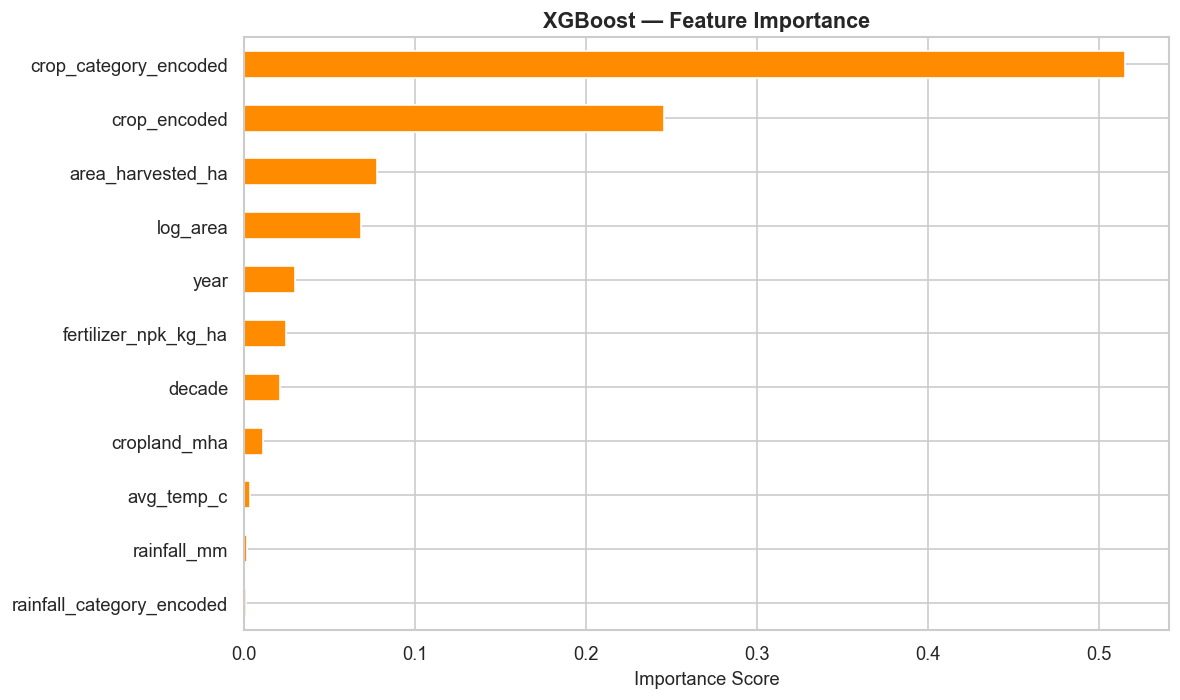

In [113]:
fig, ax = plt.subplots(figsize=(10, 6))
xgb_imp.sort_values().plot(kind='barh', ax=ax, color='darkorange', edgecolor='white')
ax.set_title('XGBoost — Feature Importance', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 5. Model Comparison

Comparing all 4 models on R², MAE, RMSE and 5-fold CV on test set (2016–2024).

In [92]:
print("\n\n" + "-"*60)
print("  MODEL COMPARISON")
print("-"*60)

results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
results_df.insert(0, 'Rank', range(1, len(results_df)+1))
print("\n" + results_df.to_string(index=False))

best_name = results_df.iloc[0]['Model']
print(f"\n  Best Model : {best_name}  (R² = {results_df.iloc[0]['R²']})")



------------------------------------------------------------
  MODEL COMPARISON
------------------------------------------------------------

 Rank             Model     R²    MAE    RMSE
    1           XGBoost 0.9032 1859.0  3686.9
    2     Random Forest 0.8653 1792.7  4349.5
    3     Decision Tree 0.5740 3628.8  7734.8
    4 Linear Regression 0.0101 8139.3 11791.1

  Best Model : XGBoost  (R² = 0.9032)


C:\Users\keshav\AppData\Local\Temp\ipykernel_21496\1772058844.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Model'], rotation=15, ha='right', fontsize=9)
C:\Users\keshav\AppData\Local\Temp\ipykernel_21496\1772058844.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Model'], rotation=15, ha='right', fontsize=9)
C:\Users\keshav\AppData\Local\Temp\ipykernel_21496\1772058844.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Model'], rotation=15, ha='right', fontsize=9)


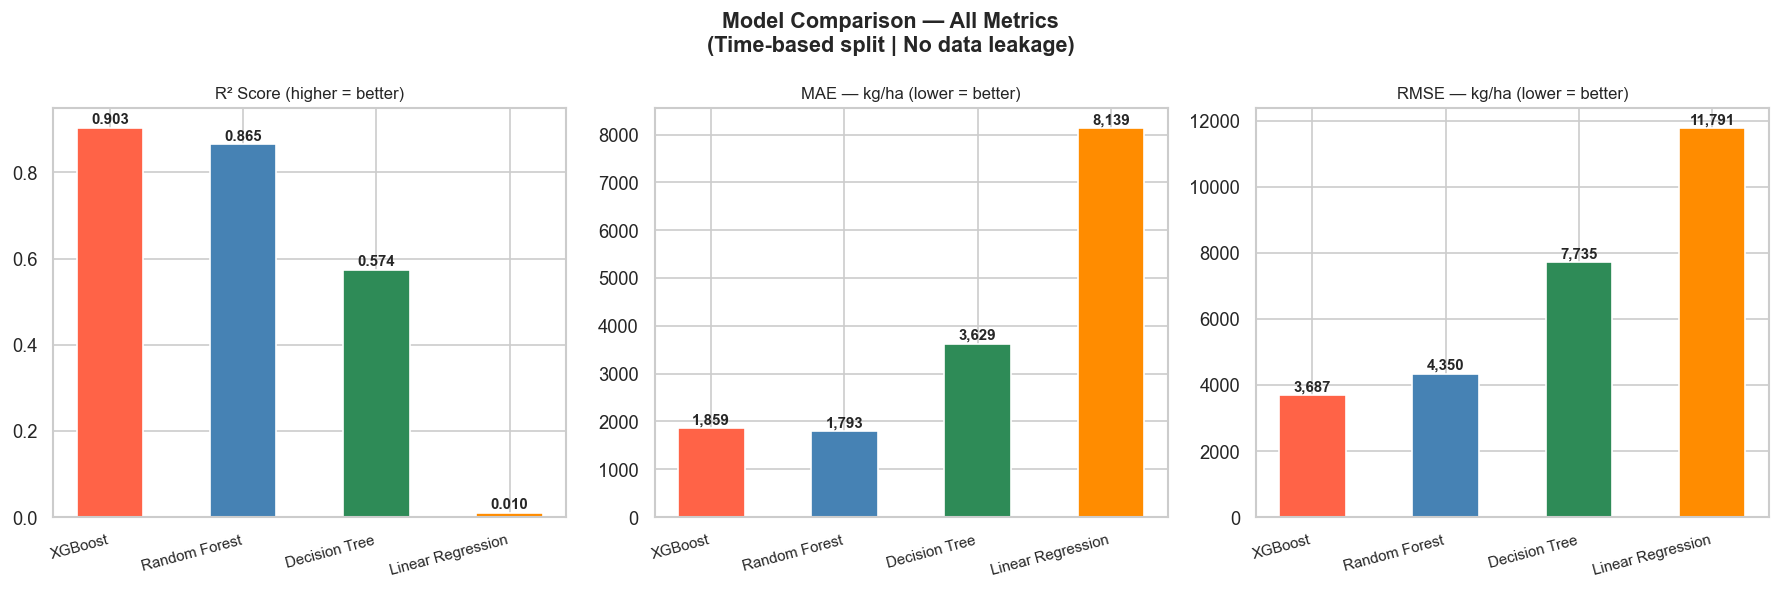

In [93]:
# Plot 1 — Metric comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison — All Metrics\n(Time-based split | No data leakage)',
             fontsize=13, fontweight='bold')
colors = ['tomato', 'steelblue', 'seagreen', 'darkorange']

for ax, metric, title in zip(axes,
    ['R²', 'MAE', 'RMSE'],
    ['R² Score (higher = better)',
     'MAE — kg/ha (lower = better)',
     'RMSE — kg/ha (lower = better)']):
    bars = ax.bar(results_df['Model'], results_df[metric],
                  color=colors[:len(results_df)], edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_xticklabels(results_df['Model'], rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(results_df[metric])*0.01,
                f'{val:.3f}' if metric == 'R²' else f'{val:,.0f}',
                ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

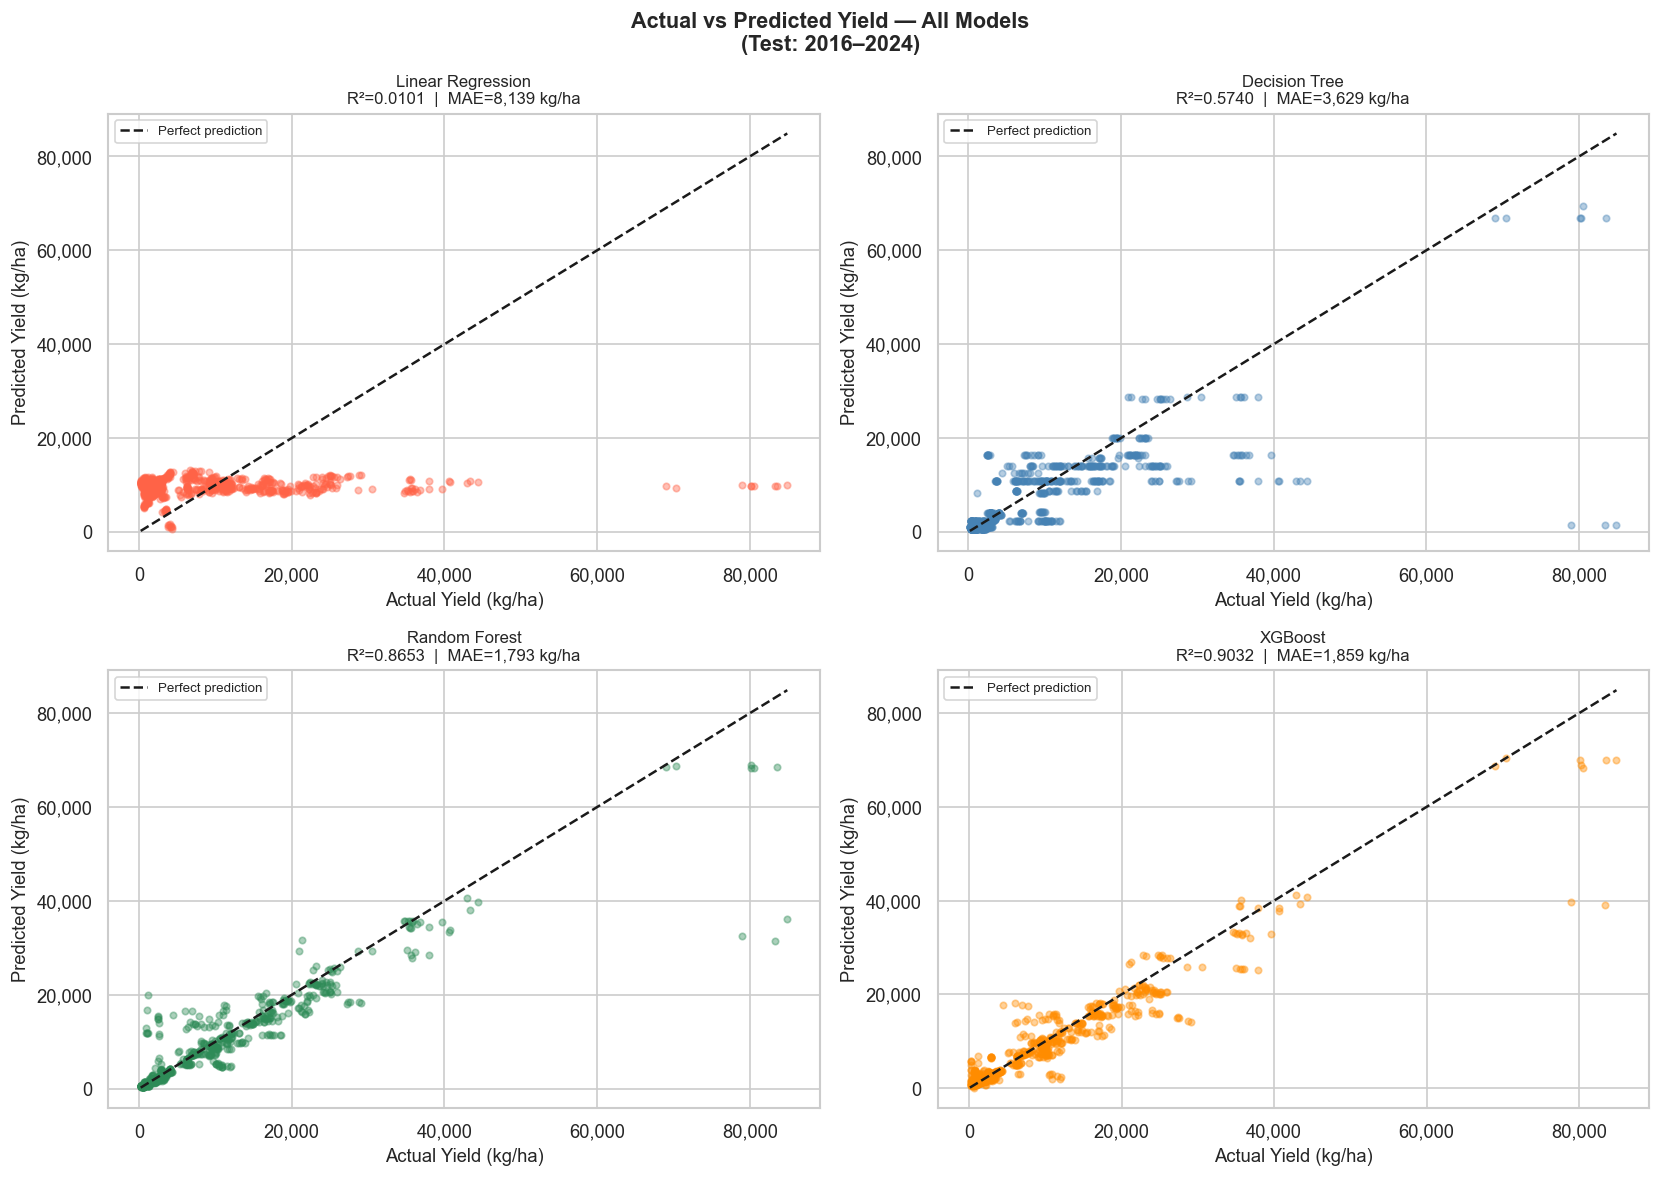

In [94]:

# Plot 2 — Actual vs Predicted
all_preds  = [pred_lr, pred_dt, pred_rf, pred_xgb]
all_names  = ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
all_colors = ['tomato', 'steelblue', 'seagreen', 'darkorange']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Actual vs Predicted Yield — All Models\n(Test: 2016–2024)',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for ax, pred, name, color in zip(axes, all_preds, all_names, all_colors):
    ax.scatter(y_test, pred, alpha=0.4, s=15, color=color)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect prediction')
    ax.set_title(
        f'{name}\nR²={r2_score(y_test,pred):.4f}  |  MAE={mean_absolute_error(y_test,pred):,.0f} kg/ha',
        fontsize=10)
    ax.set_xlabel('Actual Yield (kg/ha)')
    ax.set_ylabel('Predicted Yield (kg/ha)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

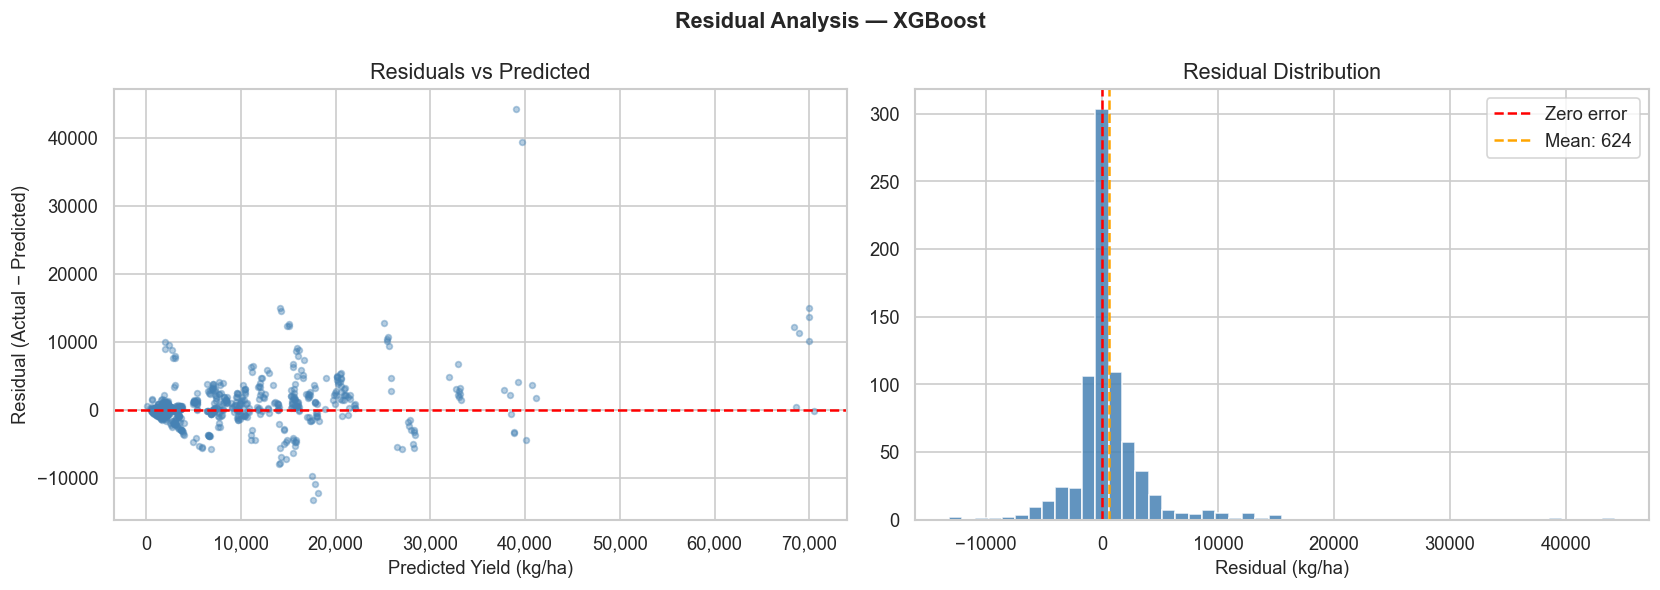

In [ ]:

#Plot 3 — Residuals for best model
best_pred = {'Linear Regression': pred_lr, 'Decision Tree': pred_dt,
             'Random Forest': pred_rf, 'XGBoost': pred_xgb}[best_name]
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Residual Analysis — {best_name}', fontsize=13, fontweight='bold')

axes[0].scatter(best_pred, residuals, alpha=0.4, s=12, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted Yield (kg/ha)')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
axes[1].axvline(residuals.mean(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Mean: {residuals.mean():,.0f}')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (kg/ha)')
axes[1].legend()
plt.tight_layout()
plt.show()

C:\Users\keshav\AppData\Local\Temp\ipykernel_21496\2960419499.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(all_names, rotation=15, ha='right')


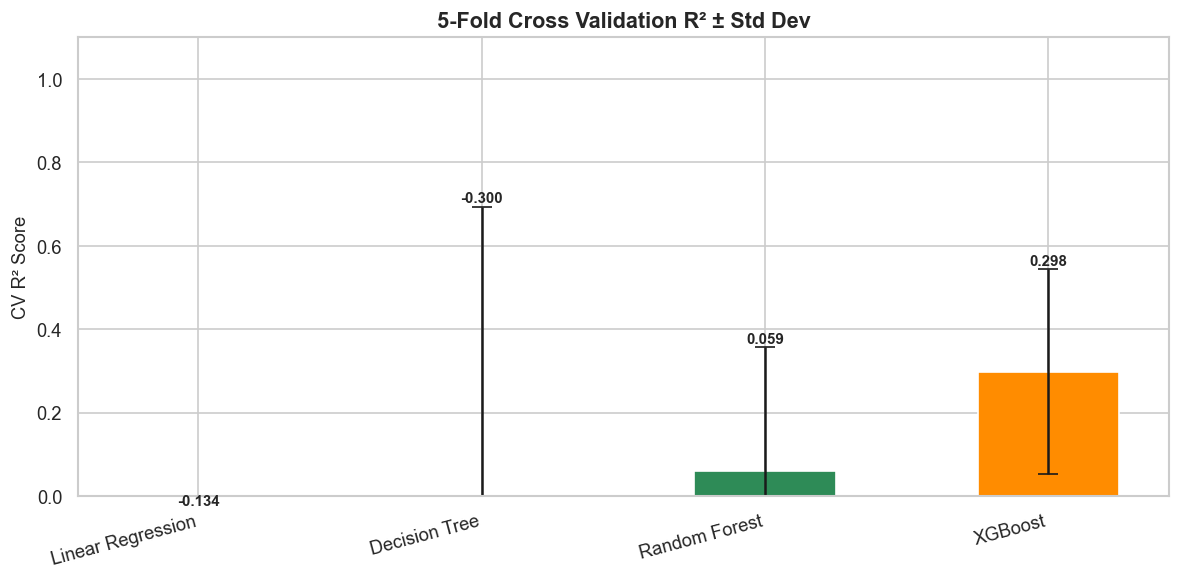

In [96]:
# Plot 4 — Cross Validation
cv_means = [cv_lr.mean(), cv_dt.mean(), cv_rf.mean(), cv_xgb.mean()]
cv_stds  = [cv_lr.std(),  cv_dt.std(),  cv_rf.std(),  cv_xgb.std()]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(all_names, cv_means, yerr=cv_stds,
              color=all_colors, edgecolor='white', width=0.5, capsize=6)
ax.set_title('5-Fold Cross Validation R² ± Std Dev', fontweight='bold')
ax.set_ylabel('CV R² Score')
ax.set_xticklabels(all_names, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
for bar, val, std in zip(bars, cv_means, cv_stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + std + 0.01,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

In [97]:

results_df.to_csv('model_comparison_results.csv', index=False)
print("   Saved: model_comparison_results.csv")

   Saved: model_comparison_results.csv


In [98]:
print("\n" + "-" * 60)
print("  FINAL RESULTS SUMMARY")
print("  Train: 1961–2015  |  Test: 2016–2024")
print("  Features: 11 (production_tonnes excluded — no leakage)")
print("-" * 60)
print(results_df.to_string(index=False))
print(f"\n   Best Model : {best_name}")
print(f"   R²         : {results_df.iloc[0]['R²']}")
print(f"   MAE        : {results_df.iloc[0]['MAE']:,} kg/ha")
print(f"   RMSE       : {results_df.iloc[0]['RMSE']:,} kg/ha")
print("\n  Plots saved:")
for p in ['plot_dt_depth_tuning.png', 'plot_rf_feature_importance.png',
          'plot_xgb_feature_importance.png', 'plot_model_comparison.png',
          'plot_actual_vs_predicted.png', 'plot_residuals.png',
          'plot_cross_validation.png']:
    print(f"    {p}")
print("-" * 60)
print("\n Model building complete — leakage free!")


------------------------------------------------------------
  FINAL RESULTS SUMMARY
  Train: 1961–2015  |  Test: 2016–2024
  Features: 11 (production_tonnes excluded — no leakage)
------------------------------------------------------------
 Rank             Model     R²    MAE    RMSE
    1           XGBoost 0.9032 1859.0  3686.9
    2     Random Forest 0.8653 1792.7  4349.5
    3     Decision Tree 0.5740 3628.8  7734.8
    4 Linear Regression 0.0101 8139.3 11791.1

   Best Model : XGBoost
   R²         : 0.9032
   MAE        : 1,859.0 kg/ha
   RMSE       : 3,686.9 kg/ha

  Plots saved:
    plot_dt_depth_tuning.png
    plot_rf_feature_importance.png
    plot_xgb_feature_importance.png
    plot_model_comparison.png
    plot_actual_vs_predicted.png
    plot_residuals.png
    plot_cross_validation.png
------------------------------------------------------------

 Model building complete — leakage free!


## 6. Saving & Inference Test

Saving XGBoost + encoders as `.pkl` for the API later.

In [99]:
import joblib

joblib.dump(xgb,     'xgboost_model.pkl')
joblib.dump(le_crop, 'le_crop.pkl')
joblib.dump(le_cat,  'le_category.pkl')
joblib.dump(le_rain, 'le_rainfall_category.pkl')

print("Model saved: xgboost_model.pkl")
print("Encoders saved: le_crop.pkl, le_category.pkl, le_rainfall_category.pkl")

Model saved: xgboost_model.pkl
Encoders saved: le_crop.pkl, le_category.pkl, le_rainfall_category.pkl


### 6.1 Reload & Sanity Check

In [100]:
import joblib
import pandas as pd
import numpy as np

# Reload model and encoders
xgb_loaded     = joblib.load('xgboost_model.pkl')
le_crop_loaded = joblib.load('le_crop.pkl')
le_cat_loaded  = joblib.load('le_category.pkl')
le_rain_loaded = joblib.load('le_rainfall_category.pkl')

print("Model and encoders loaded successfully")
print(f"   Model type : {type(xgb_loaded).__name__}")
print(f"   Crops known: {len(le_crop_loaded.classes_)}")
print(f"   Categories : {list(le_cat_loaded.classes_)}")

Model and encoders loaded successfully
   Model type : XGBRegressor
   Crops known: 85
   Categories : ['Beverage', 'Cash Crop', 'Cereal', 'Fibre', 'Fruit', 'Industrial', 'Oilseed', 'Other', 'Pulse', 'Root Crop', 'Spice', 'Tree Nut', 'Vegetable']


### 6.2 Sample Predictions

In [103]:
# Pick 10 random rows from test set
sample = X_test.sample(10, random_state=42).copy()
sample_preds = xgb_loaded.predict(sample)

sample_results = pd.DataFrame({
    'crop'          : le_crop_loaded.inverse_transform(sample['crop_encoded']),
    'year'          : sample['year'].values,
    'actual_yield'  : y_test.loc[sample.index].values,
    'predicted_yield': np.round(sample_preds, 1),
})

sample_results['error_kg_ha'] = (
    sample_results['actual_yield'] - sample_results['predicted_yield']
).round(1)

sample_results['error_%'] = (
    (sample_results['error_kg_ha'].abs() / sample_results['actual_yield']) * 100
).round(2)

print("── Sample Predictions (Test Set 2016–2024) ──\n")
print(sample_results.to_string(index=False))
print(f"\nMean absolute error on sample : {sample_results['error_kg_ha'].abs().mean():,.1f} kg/ha")

── Sample Predictions (Test Set 2016–2024) ──

                                                        crop  year  actual_yield  predicted_yield  error_kg_ha  error_%
                                          Rape or colza seed  2019        1511.4      1195.900024        315.5    20.87
                             Natural rubber in primary forms  2021        2219.9      1610.099976        609.8    27.47
                                   Cauliflowers and broccoli  2023       19446.0     17081.000000       2365.0    12.16
                                                Green garlic  2023        8524.4      9657.299805      -1132.9    13.29
                                                Lentils, dry  2018        1046.9      1088.099976        -41.2     3.94
                                                     Oranges  2017       16782.8     11191.500000       5591.3    33.32
                             Mangoes, guavas and mangosteens  2019        9965.1      8456.200195       1508.9   

## 7. Explainable AI — SHAP
Explaining XGBoost predictions using SHAP (SHapley Additive exPlanations).
Tells us *why* the model predicted a certain yield for each input.

In [114]:
import shap

In [115]:
explainer  = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
print("SHAP values computed")

SHAP values computed


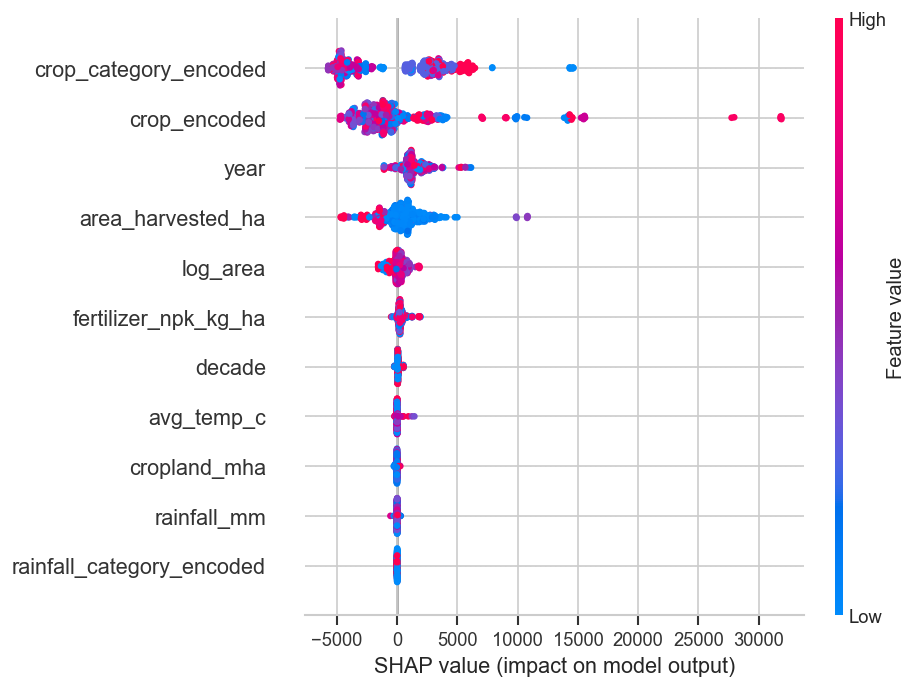

In [116]:
# Summary plot — overall feature impact
shap.summary_plot(shap_values, X_test, feature_names=FEATURES)

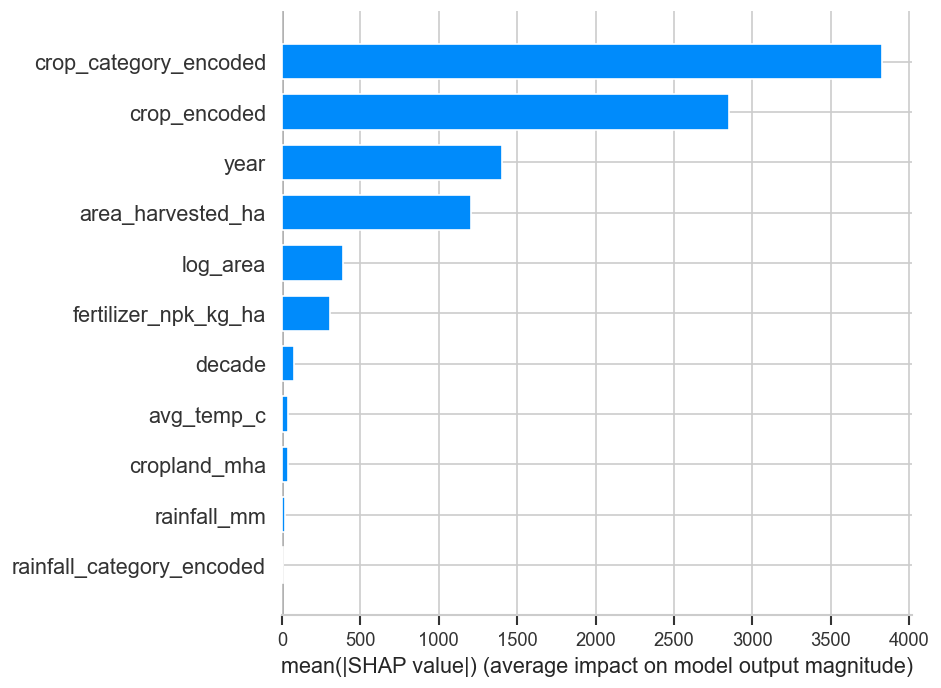

In [117]:
# Bar plot — mean importance (better than default feature importance)
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, plot_type='bar')

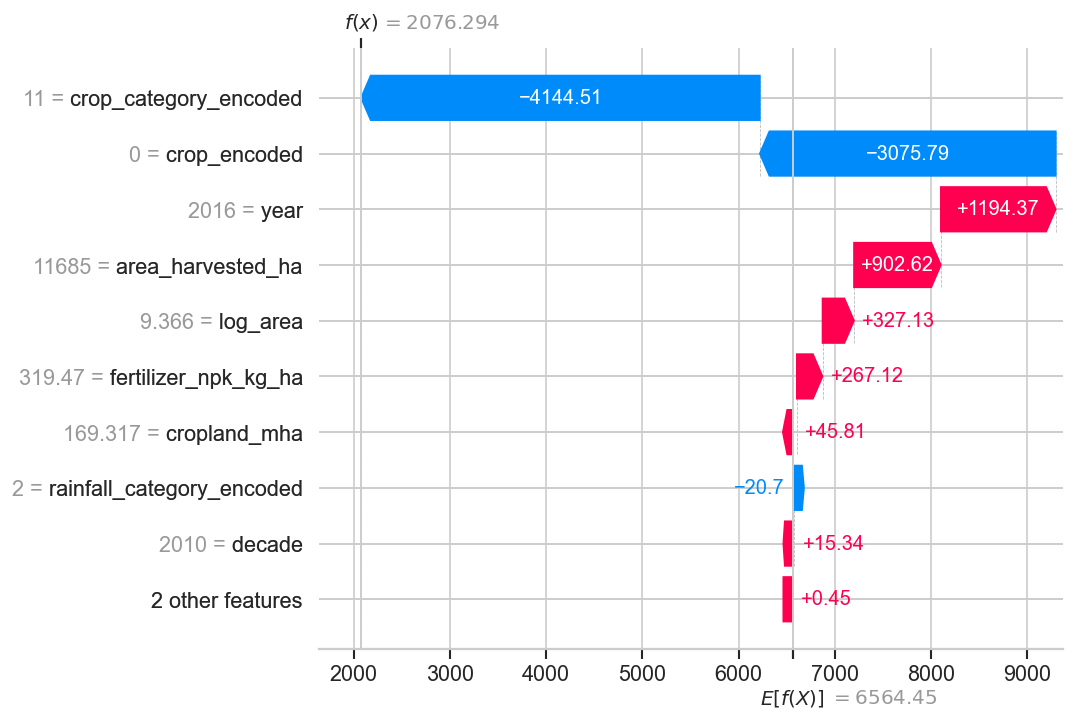

In [118]:
# Waterfall — explain a single prediction (first test row)
shap.plots.waterfall(explainer(X_test)[0])

In [121]:
# Human-readable explanation for a single prediction
exp = explainer(X_test)
idx = 0  # change to any row index

base  = exp.base_values[idx]
vals  = exp.values[idx]
feats = X_test.iloc[idx]

contributions = pd.DataFrame({
    'feature': FEATURES,
    'value':   feats.values,
    'shap':    vals
}).sort_values('shap', key=abs, ascending=False)

print(f"Prediction Explanation — Row {idx}")
print(f"   Baseline (average) yield : {base:,.1f} kg/ha")
print(f"   Final prediction         : {base + vals.sum():,.1f} kg/ha\n")
print("   Top factors:")
for _, row in contributions.head(6).iterrows():
    direction = "pushed UP 🡹 " if row['shap'] > 0 else "pushed DOWN 🡻"
    print(f"   {row['feature']:<30} = {row['value']:>10.2f}  →  {direction} by {abs(row['shap']):,.1f}")

Prediction Explanation — Row 0
   Baseline (average) yield : 6,564.4 kg/ha
   Final prediction         : 2,076.3 kg/ha

   Top factors:
   crop_category_encoded          =      11.00  →  pushed DOWN 🡻 by 4,144.5
   crop_encoded                   =       0.00  →  pushed DOWN 🡻 by 3,075.8
   year                           =    2016.00  →  pushed UP 🡹  by 1,194.4
   area_harvested_ha              =   11685.00  →  pushed UP 🡹  by 902.6
   log_area                       =       9.37  →  pushed UP 🡹  by 327.1
   fertilizer_npk_kg_ha           =     319.47  →  pushed UP 🡹  by 267.1
